In [1]:
import os
import gc
import glob
import json
#import h5py
import numpy as np
import pickle
import pandas as pd
#from IPython.display import Audio, display
from collections import Counter, defaultdict
from pynwb import NWBHDF5IO
from datetime import datetime
import scipy.signal
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate
from scipy.stats import kurtosis, skew

In [2]:
from extract_features import extractHG, stackFeatures, downsampleLabels
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
#from feature_vizualizer import PhonemeFeatureVisualizer
from markov_phoneme_model import MarkovPhonemeModel
from extract_features import extractHG, downsampleLabels, extractMelSpecs
from pipeline import UnifiedPhonemePipeline
from phoneme_group_analyzer import PHONEME_GROUPS
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [3]:
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic 
from dataset_config import Dutch30Config

from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch

In [4]:
# plt.ion()

In [5]:
dutch30_dir = DUTCH_30_PATH

# List all .npy files for one patient
patient_files = glob.glob(os.path.join(dutch30_dir, 'P01*.npy'))

In [6]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [7]:
# Create config
# config = Dutch30Config()

# # Pass config to both extractor and pipeline
# extractor = Dutch30FeatureExtractor(config=config)

# pipeline = Dutch30Pipeline(
#     dutch30_extractor=extractor,
#     config=config, 
#     debug_mode=True,
#     pca_components=100,
#     feature_extraction_method='high_gamma', 
    
# )

# # Debug a specific patient
# pipeline.debug_sentence_parsing('sub-p21', max_samples=3)
# print([attr for attr in dir(pipeline_debug) if 'detect' in attr.lower()])

In [8]:
# Load pre-trained wav2vec model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", use_safetensors=True)
config = Dutch30Config()
extractor = Dutch30FeatureExtractor()

C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz


In [9]:
# #check where method is used
# import os

# search_term = "standardize_channels"
# project_path = r"D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch_step2"

# for filename in os.listdir(project_path):
#     if filename.endswith('.py'):
#         filepath = os.path.join(project_path, filename)
#         with open(filepath, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#             for line_num, line in enumerate(lines, 1):
#                 if search_term in line and 'def ' not in line and not line.strip().startswith('#'):
#                     print(f"{filename}:{line_num}: {line.strip()}")

In [10]:
# pipeline.step1_load_dutch30_data(num_patients = 10)
# #pipeline.step2_3_use_existing_split()
# pipeline.step2_split_by_instances()

# pid = 'P01'
# word_segments = pipeline.split_result['word_segments_dict'][pid]
# word = list(word_segments['words'].keys())[0]
# instance = word_segments['words'][word]['instances'][0]

# print(f"Audio available: {'audio_segment' in instance}")
# print(f"Audio shape: {instance['audio_segment'].shape if 'audio_segment' in instance else 'N/A'}")

In [11]:
config = Dutch30Config()
extractor = Dutch30FeatureExtractor(config=config)
high_gamma_pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    config=config, 
    debug_mode=False,
    pca_components= None, #100,
    feature_extraction_method = 'high_gamma',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
    use_rms_boundaries=False,   
    use_multifeature=False,
    use_wav2vec=True,
    subtract_baseline=False,
    #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
)

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 1 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=None, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: A

In [12]:
# step_0
# pipeline.analyze_dutch30_channels()
#pipeline.step1_load_dutch30_data(num_patients = 20)
#best_patients = ['P03', 'P11', 'P16', 'P17', 'P21']
#pipeline.step1_load_dutch30_data(patient_ids=best_patients)

high_gamma_pipeline.step1_load_dutch30_data(patient_range=(1,30))

high_gamma_pipeline.split_result = None
high_gamma_pipeline.step2_split_by_instances();

#high_gamma_pipeline.step3_analyze_channel_quality()
#high_gamma_pipeline.step3_analyze_channel_quality(visualize=True)

UnifiedPhonemePipeline: Step 1: Loading Dutch30...
UnifiedPhonemePipeline:   Using patients P01 to P30: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline: P01: 70 train, 31 test, baseline: (130,)
UnifiedPhonemePipeline: P02: 68 train, 33 test, baseline: (130,)
UnifiedPhonemePipeline: P03: 71 train, 30 test, baseline: (133,)
UnifiedPhonemePipeline: P04: 78 train, 23 test, baseline: (128,)
UnifiedPhonemePipeline: P06: 76 train, 25 test, baseline: (133,)
UnifiedPhonemePipeline: P07: 66 train, 35 test, baseline: (130,)
UnifiedPhonemePipeline: P08: 68 train, 33 test, baseline: (127,)
UnifiedPhonemePipeline: P09: 81 train, 19 test, baseline: (125,)
UnifiedPhonemePipeline: P10: 62 train, 34 test, baseline: (125,)
UnifiedPhonemePipeline: P11: 60 train, 40 test, baseline: (130,)
UnifiedPhonemePipeline: P12: 60 train, 40 test, baseline

In [13]:
# band_powers_pipeline.step4_custom_detector()
high_gamma_pipeline.step4_custom_detector()
# hjorth_pipeline.step4_custom_detector()

UnifiedPhonemePipeline: Step 4: Initializing detector...
AcousticChangeDetector: Initialized with DEBUG_MODE=False
AcousticChangeDetector: Using feature extraction method: high_gamma
AcousticChangeDetector: Initializing wav2vec model for boundary detection...


C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


AcousticChangeDetector: Wav2vec model initialized successfully


In [14]:
# band_powers_pipeline.step5_accumulate_data_dutch30();
high_gamma_pipeline.step5_accumulate_data_dutch30();
# hjorth_pipeline.step5_accumulate_data_dutch30();

UnifiedPhonemePipeline: 
Step 5 starting:
UnifiedPhonemePipeline:   Train patients: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline:   Available samples: train=4816, test=2496
AcousticChangeDetector: Processing 4816 instances in 38 batches (no replacement)
AcousticChangeDetector: Processing batch 1/38
          Building batch from 128 instances...
          Batch built: 128 words
          Processing batch (phoneme detection)...
AcousticChangeDetector:   Need 10 peaks but only found 5 for word 'zevenduizend' (Patient P01)
AcousticChangeDetector:   Need 10 peaks but only found 9 for word 'vogelkooitje' (Patient P01)
AcousticChangeDetector:   Need 12 peaks but only found 11 for word 'teruggekregen' (Patient P01)
AcousticChangeDetector:   Need 6 peaks but only found 5 for word 'helemaal' (Patient P01)
AcousticChangeDetector:  

In [16]:
# band_powers_pipeline.dutch30_step6_resolve_unknowns();
high_gamma_pipeline.dutch30_step6_resolve_unknowns();
# hjorth_pipeline.dutch30_step6_resolve_unknowns();

UnifiedPhonemePipeline: Train data keys: dict_keys(['features', 'phoneme_labels', 'phoneme_words', 'phoneme_positions', 'phoneme_participant_ids', 'phoneme_durations_samples', 'spectrograms', 'metadata'])
UnifiedPhonemePipeline: Unknown count: 5683
PhonemeValidator: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Step 6: Validator initialized
UnifiedPhonemePipeline: Resolving 5683 unknown phonemes in training...
UnifiedPhonemePipeline: Test unknowns: 2621
UnifiedPhonemePipeline: WARNING: Still 97 unknown in train, 30 in test
UnifiedPhonemePipeline: Step 6 complete: 17646 train, 8691 test
UnifiedPhonemePipeline:   Unknown remaining: 97 train, 30 test


In [18]:
# band_powers_pipeline.checkpoint_after_step6()
high_gamma_pipeline.checkpoint_after_step6()
# band_powers_pipeline.checkpoint_after_step6(sample_fraction=1)
# high_gamma_pipeline.checkpoint_after_step6(sample_fraction=1)
# hjorth_pipeline.checkpoint_after_step6(sample_fraction=1)

UnifiedPhonemePipeline: Saving checkpoint: pipeline_high_gamma_pcaNone_after_step6_20260117_111635.pkl
UnifiedPhonemePipeline: Checkpoint saved: pipeline_high_gamma_pcaNone_after_step6_20260117_111635.pkl


'C:\\mozg\\code\\SingleWordProductionDutch\\results\\dutch30\\pipeline_high_gamma_pcaNone_after_step6_20260117_111635.pkl'

In [19]:
high_gamma_pipeline.try_load_checkpoint()
# pipeline.try_load_checkpoint(sample_fraction=0.0001)

UnifiedPhonemePipeline: Loading checkpoint: pipeline_high_gamma_pcaNone_after_step6_20260117_111635.pkl
UnifiedPhonemePipeline: Checkpoint loaded: train=17646, test=8691 samples


True

In [20]:
# band_powers_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);
high_gamma_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);
# hjorth_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);

UnifiedPhonemePipeline: Filtered training: 17556 samples (from 17646)


In [23]:
def summarize_all_patients(pipeline, patient_ids, min_samples=5, save_path=None):
    """
    Loop through all patients and summarize which phoneme comparisons each is good for.
    
    Args:
        pipeline: Dutch30Pipeline with train data for multiple patients
        patient_ids: List of patient IDs to analyze
        min_samples: Minimum samples per group to include comparison
        save_path: Directory to save results
    
    Returns:
        dict: Summary results with rankings
    """
    from collections import defaultdict
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    import os
    from phoneme_group_analyzer import extract_summary_features, COMPARISONS, PHONEME_GROUPS, cohens_d
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data.")
    
    train_data = pipeline.train
    features_list = train_data['features']
    labels = train_data['phoneme_labels']
    participant_ids = train_data['phoneme_participant_ids']
    
    # Store all results
    all_results = []
    
    for pid in patient_ids:
        print(f"\nProcessing {pid}...")
        
        # Filter to this patient
        indices = [i for i, p in enumerate(participant_ids) if p == pid]
        
        if not indices:
            print(f"  No data for {pid}")
            continue
        
        pat_features = [features_list[i] for i in indices]
        pat_labels = [labels[i] for i in indices]
        
        # Extract summary features
        summaries = []
        valid_indices = []
        
        for i, feat in enumerate(pat_features):
            s = extract_summary_features(feat)
            if s is not None:
                summaries.append(s)
                valid_indices.append(i)
        
        pat_labels = [pat_labels[i] for i in valid_indices]
        
        if len(summaries) == 0:
            print(f"  No valid samples for {pid}")
            continue
        
        feature_names = list(summaries[0].keys())
        X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
        # Test each comparison
        for group1_name, group2_name, comparison_name in COMPARISONS:
            group1 = PHONEME_GROUPS[group1_name]
            group2 = PHONEME_GROUPS[group2_name]
            
            idx_g1 = [i for i, label in enumerate(pat_labels) if label in group1]
            idx_g2 = [i for i, label in enumerate(pat_labels) if label in group2]
            
            n1, n2 = len(idx_g1), len(idx_g2)
            
            if n1 < min_samples or n2 < min_samples:
                continue
            
            # Calculate best Cohen's d
            best_d = 0
            best_feat = None
            for j, feat_name in enumerate(feature_names):
                g1_vals = X[idx_g1, j]
                g2_vals = X[idx_g2, j]
                d = cohens_d(g1_vals, g2_vals)
                if d > best_d:
                    best_d = d
                    best_feat = feat_name
            
            # Classification
            y_binary = np.array([0]*n1 + [1]*n2)
            X_binary = np.vstack([X[idx_g1], X[idx_g2]])
            baseline = max(n1, n2) / (n1 + n2)
            
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_binary)
            
            clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            cv = StratifiedKFold(n_splits=min(5, min(n1, n2)), shuffle=True, random_state=42)
            
            try:
                scores = cross_val_score(clf, X_scaled, y_binary, cv=cv, scoring='accuracy')
                accuracy = np.mean(scores)
            except:
                accuracy = baseline
            
            lift = accuracy / baseline
            
            all_results.append({
                'patient': pid,
                'comparison': comparison_name,
                'group1': group1_name,
                'group2': group2_name,
                'n1': n1,
                'n2': n2,
                'total_samples': n1 + n2,
                'baseline': baseline,
                'accuracy': accuracy,
                'lift': lift,
                'cohens_d': best_d,
                'best_feature': best_feat,
                'promising': lift > 1.05 and best_d > 0.25
            })
    
    # Create DataFrame
    df = pd.DataFrame(all_results)
    
    if len(df) == 0:
        print("No results!")
        return None
    
    # Print summary tables
    print("\n" + "="*80)
    print("SUMMARY: BEST COMPARISON PER PATIENT")
    print("="*80)
    
    best_per_patient = df.loc[df.groupby('patient')['lift'].idxmax()]
    best_per_patient = best_per_patient.sort_values('lift', ascending=False)
    
    print(best_per_patient[['patient', 'comparison', 'lift', 'cohens_d', 'total_samples', 'best_feature']].to_string(index=False))
    
    print("\n" + "="*80)
    print("SUMMARY: BEST PATIENT PER COMPARISON")
    print("="*80)
    
    best_per_comparison = df.loc[df.groupby('comparison')['lift'].idxmax()]
    best_per_comparison = best_per_comparison.sort_values('lift', ascending=False)
    
    print(best_per_comparison[['comparison', 'patient', 'lift', 'cohens_d', 'total_samples']].to_string(index=False))
    
    print("\n" + "="*80)
    print("ALL PROMISING RESULTS (lift > 1.05 AND d > 0.25)")
    print("="*80)
    
    promising = df[df['promising']].sort_values('lift', ascending=False)
    
    if len(promising) > 0:
        print(promising[['patient', 'comparison', 'lift', 'cohens_d', 'total_samples', 'best_feature']].to_string(index=False))
    else:
        print("No promising results found.")
    
    print("\n" + "="*80)
    print("VOWEL COMPARISONS RANKED BY LIFT")
    print("="*80)
    
    vowel_comps = ['Front vs Back Vowels', 'Short vs Long Vowels', 'Front vs Back (Short)', 'Front vs Back (Long)']
    vowel_df = df[df['comparison'].isin(vowel_comps)].sort_values('lift', ascending=False)
    
    if len(vowel_df) > 0:
        print(vowel_df[['patient', 'comparison', 'lift', 'cohens_d', 'total_samples']].head(15).to_string(index=False))
    
    print("\n" + "="*80)
    print("CONSONANT COMPARISONS RANKED BY LIFT")
    print("="*80)
    
    consonant_df = df[~df['comparison'].isin(vowel_comps)].sort_values('lift', ascending=False)
    
    if len(consonant_df) > 0:
        print(consonant_df[['patient', 'comparison', 'lift', 'cohens_d', 'total_samples']].head(15).to_string(index=False))
    
    # Save to CSV
    if save_path:
        df.to_csv(os.path.join(save_path, 'all_patient_comparisons.csv'), index=False)
        promising.to_csv(os.path.join(save_path, 'promising_results.csv'), index=False)
        print(f"\nSaved results to {save_path}")
    
    return {
        'all_results': df,
        'best_per_patient': best_per_patient,
        'best_per_comparison': best_per_comparison,
        'promising': promising,
        'vowel_results': vowel_df,
        'consonant_results': consonant_df
    }

In [24]:
def create_classification_heatmaps(results_df, electrode_df, save_path=None):
    """
    Create heatmaps showing patient performance across phoneme comparisons
    and electrode coverage.
    
    Args:
        results_df: DataFrame from summarize_all_patients['all_results']
        electrode_df: DataFrame from analyze_electrode_locations_all_patients
        save_path: Optional path to save figures
    """
    import os
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # =========================================================================
    # HEATMAP 1: Patients x Comparisons (Lift values)
    # =========================================================================
    
    # Pivot the results to create patient x comparison matrix
    pivot_lift = results_df.pivot_table(
        index='patient', 
        columns='comparison', 
        values='lift', 
        aggfunc='first'
    )
    
    # Sort patients by best lift
    patient_order = electrode_df.sort_values('best_lift', ascending=False)['patient'].tolist()
    pivot_lift = pivot_lift.reindex(patient_order)
    
    # Define comparison order (vowels first, then consonants)
    vowel_comps = ['Front vs Back Vowels', 'Front vs Back (Short)', 'Front vs Back (Long)', 'Short vs Long Vowels']
    consonant_comps = ['Labial vs Velar', 'Labial vs Alveolar', 'Alveolar vs Velar',
                       'Plosives vs Fricatives', 'Plosives vs Nasals', 'Fricatives vs Nasals',
                       'Nasals vs Liquids/Glides', 'Plosives vs Liquids/Glides', 'Voiced vs Voiceless']
    
    comp_order = [c for c in vowel_comps + consonant_comps if c in pivot_lift.columns]
    pivot_lift = pivot_lift[comp_order]
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Create mask for NaN values
    mask = pivot_lift.isna()
    
    # Custom colormap: red below 1.0, white at 1.0, green above 1.0
    sns.heatmap(pivot_lift, 
                annot=True, 
                fmt='.2f', 
                cmap='RdYlGn',
                center=1.0,
                vmin=0.8,
                vmax=1.4,
                mask=mask,
                linewidths=0.5,
                ax=ax,
                annot_kws={'size': 8})
    
    ax.set_title('Classification Lift by Patient and Comparison\n(Green = above baseline, Red = below baseline)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Phoneme Comparison', fontsize=12)
    ax.set_ylabel('Patient (sorted by best lift)', fontsize=12)
    
    # Add vertical line between vowels and consonants
    n_vowels = len([c for c in vowel_comps if c in pivot_lift.columns])
    ax.axvline(x=n_vowels, color='black', linewidth=2)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, 'heatmap_patients_comparisons.png'), dpi=150, bbox_inches='tight')
        print(f"Saved: heatmap_patients_comparisons.png")
    
    plt.show()
    
    # =========================================================================
    # HEATMAP 2: Patients x Electrode Regions
    # =========================================================================
    
    region_cols = ['speech_precentral', 'speech_postcentral', 'speech_inferior_frontal',
                   'speech_superior_temporal', 'speech_middle_temporal', 'speech_insula',
                   'speech_supramarginal', 'speech_angular', 'speech_subcentral']
    
    # Filter to columns that exist
    region_cols = [c for c in region_cols if c in electrode_df.columns]
    
    # Create electrode region matrix
    electrode_matrix = electrode_df.set_index('patient')[region_cols]
    electrode_matrix = electrode_matrix.reindex(patient_order)
    
    # Rename columns for readability
    electrode_matrix.columns = [c.replace('speech_', '').title() for c in electrode_matrix.columns]
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    sns.heatmap(electrode_matrix, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                linewidths=0.5,
                ax=ax,
                annot_kws={'size': 9})
    
    ax.set_title('Electrode Coverage by Brain Region\n(Number of electrodes per region)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Brain Region', fontsize=12)
    ax.set_ylabel('Patient (sorted by best lift)', fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, 'heatmap_patients_electrodes.png'), dpi=150, bbox_inches='tight')
        print(f"Saved: heatmap_patients_electrodes.png")
    
    plt.show()
    
    # =========================================================================
    # HEATMAP 3: Brain Regions x Comparisons (Average lift)
    # =========================================================================
    
    # For each region, calculate average lift for patients with electrodes there
    region_comparison_lift = {}
    
    for region in region_cols:
        region_name = region.replace('speech_', '')
        region_comparison_lift[region_name] = {}
        
        # Patients with at least 1 electrode in this region
        patients_with_region = electrode_df[electrode_df[region] > 0]['patient'].tolist()
        
        for comp in comp_order:
            if comp in results_df['comparison'].values:
                comp_results = results_df[
                    (results_df['comparison'] == comp) & 
                    (results_df['patient'].isin(patients_with_region))
                ]
                if len(comp_results) > 0:
                    region_comparison_lift[region_name][comp] = comp_results['lift'].mean()
    
    region_comp_df = pd.DataFrame(region_comparison_lift).T
    region_comp_df = region_comp_df[comp_order]
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    sns.heatmap(region_comp_df, 
                annot=True, 
                fmt='.2f', 
                cmap='RdYlGn',
                center=1.0,
                vmin=0.9,
                vmax=1.2,
                linewidths=0.5,
                ax=ax,
                annot_kws={'size': 9})
    
    ax.set_title('Average Lift by Brain Region and Comparison\n(For patients with electrodes in each region)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Phoneme Comparison', fontsize=12)
    ax.set_ylabel('Brain Region', fontsize=12)
    
    # Add vertical line between vowels and consonants
    ax.axvline(x=n_vowels, color='black', linewidth=2)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, 'heatmap_regions_comparisons.png'), dpi=150, bbox_inches='tight')
        print(f"Saved: heatmap_regions_comparisons.png")
    
    plt.show()
    
    # =========================================================================
    # HEATMAP 4: Combined summary - Best comparison per patient with electrode info
    # =========================================================================
    
    # Create summary dataframe
    summary_df = electrode_df[['patient', 'speech_ratio', 'auditory_ratio', 'motor_ratio',
                               'best_comparison', 'best_lift']].copy()
    summary_df = summary_df.sort_values('best_lift', ascending=False)
    
    # Add best vowel and consonant info
    if 'best_vowel_lift' in electrode_df.columns:
        summary_df = summary_df.merge(
            electrode_df[['patient', 'best_vowel_lift', 'best_cons_lift', 'better_at']],
            on='patient'
        )
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    
    # Left: Electrode ratios
    electrode_ratios = summary_df.set_index('patient')[['speech_ratio', 'auditory_ratio', 'motor_ratio']]
    
    sns.heatmap(electrode_ratios, 
                annot=True, 
                fmt='.2f', 
                cmap='YlOrRd',
                linewidths=0.5,
                ax=axes[0],
                annot_kws={'size': 9})
    
    axes[0].set_title('Electrode Coverage Ratios\n(Proportion of electrodes in each category)', 
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Coverage Type', fontsize=10)
    axes[0].set_ylabel('Patient (sorted by best lift)', fontsize=10)
    
    # Right: Performance (vowel vs consonant lift)
    if 'best_vowel_lift' in summary_df.columns:
        perf_df = summary_df.set_index('patient')[['best_vowel_lift', 'best_cons_lift']]
        perf_df.columns = ['Vowel Lift', 'Consonant Lift']
        
        sns.heatmap(perf_df, 
                    annot=True, 
                    fmt='.2f', 
                    cmap='RdYlGn',
                    center=1.0,
                    vmin=0.9,
                    vmax=1.4,
                    linewidths=0.5,
                    ax=axes[1],
                    annot_kws={'size': 9})
        
        axes[1].set_title('Best Vowel vs Consonant Classification\n(Green = above baseline)', 
                          fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Category', fontsize=10)
        axes[1].set_ylabel('Patient (sorted by best lift)', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, 'heatmap_summary.png'), dpi=150, bbox_inches='tight')
        print(f"Saved: heatmap_summary.png")
    
    plt.show()
    
    return {
        'lift_matrix': pivot_lift,
        'electrode_matrix': electrode_matrix,
        'region_comparison': region_comp_df,
        'summary': summary_df
    }


In [41]:
import os
import pandas as pd
from config import DUTCH_30_PATH

data_dir = os.path.join(DUTCH_30_PATH, 'raw')
patient_ids = ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 
                   'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 
                   'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']

electrode_data = []

for pid in patient_ids:
    electrode_file = os.path.join(data_dir, f'{pid}_electrode_locations.csv')
    
    if not os.path.exists(electrode_file):
        print(f"No electrode file for {pid}")
        continue
    
    df = pd.read_csv(electrode_file)
    locations = df['location'].astype(str).tolist()
    total = len(locations)
    
    # Count speech-related electrodes
    speech_patterns = ['precentral', 'postcentral', 'front_inf', 'temp_sup', 
                       'temporal_middle', 'Ins_', 'insula', 'Supramar', 'Angular']
    speech_count = sum(1 for loc in locations if any(p in loc for p in speech_patterns))
    
    electrode_data.append({
        'patient': pid,
        'total_electrodes': total,
        'speech_electrodes': speech_count,
        'speech_ratio': speech_count / total if total > 0 else 0,
    })
electrode_df = pd.DataFrame(electrode_data)

Electrode DF columns:
['patient', 'total_electrodes', 'speech_total', 'motor_total', 'auditory_total', 'white_matter', 'subcortical', 'unknown', 'speech_ratio', 'motor_ratio', 'auditory_ratio', 'speech_precentral', 'speech_postcentral', 'speech_inferior_frontal', 'speech_superior_frontal', 'speech_superior_temporal', 'speech_middle_temporal', 'speech_insula', 'speech_supramarginal', 'speech_angular', 'speech_subcentral', 'speech_cingulate', 'best_comparison', 'best_lift', 'best_vowel_lift', 'best_cons_lift', 'better_at']

Electrode DF preview:
   patient  total_electrodes  speech_total  speech_ratio  motor_ratio  auditory_ratio  best_lift
0      P01               133            18      0.135338     0.022556        0.022556   1.179740
1      P02               234            34      0.145299     0.000000        0.106838   1.120353
2      P03               184            46      0.250000     0.005435        0.065217   0.985474
3      P04               117            47      0.401709     0

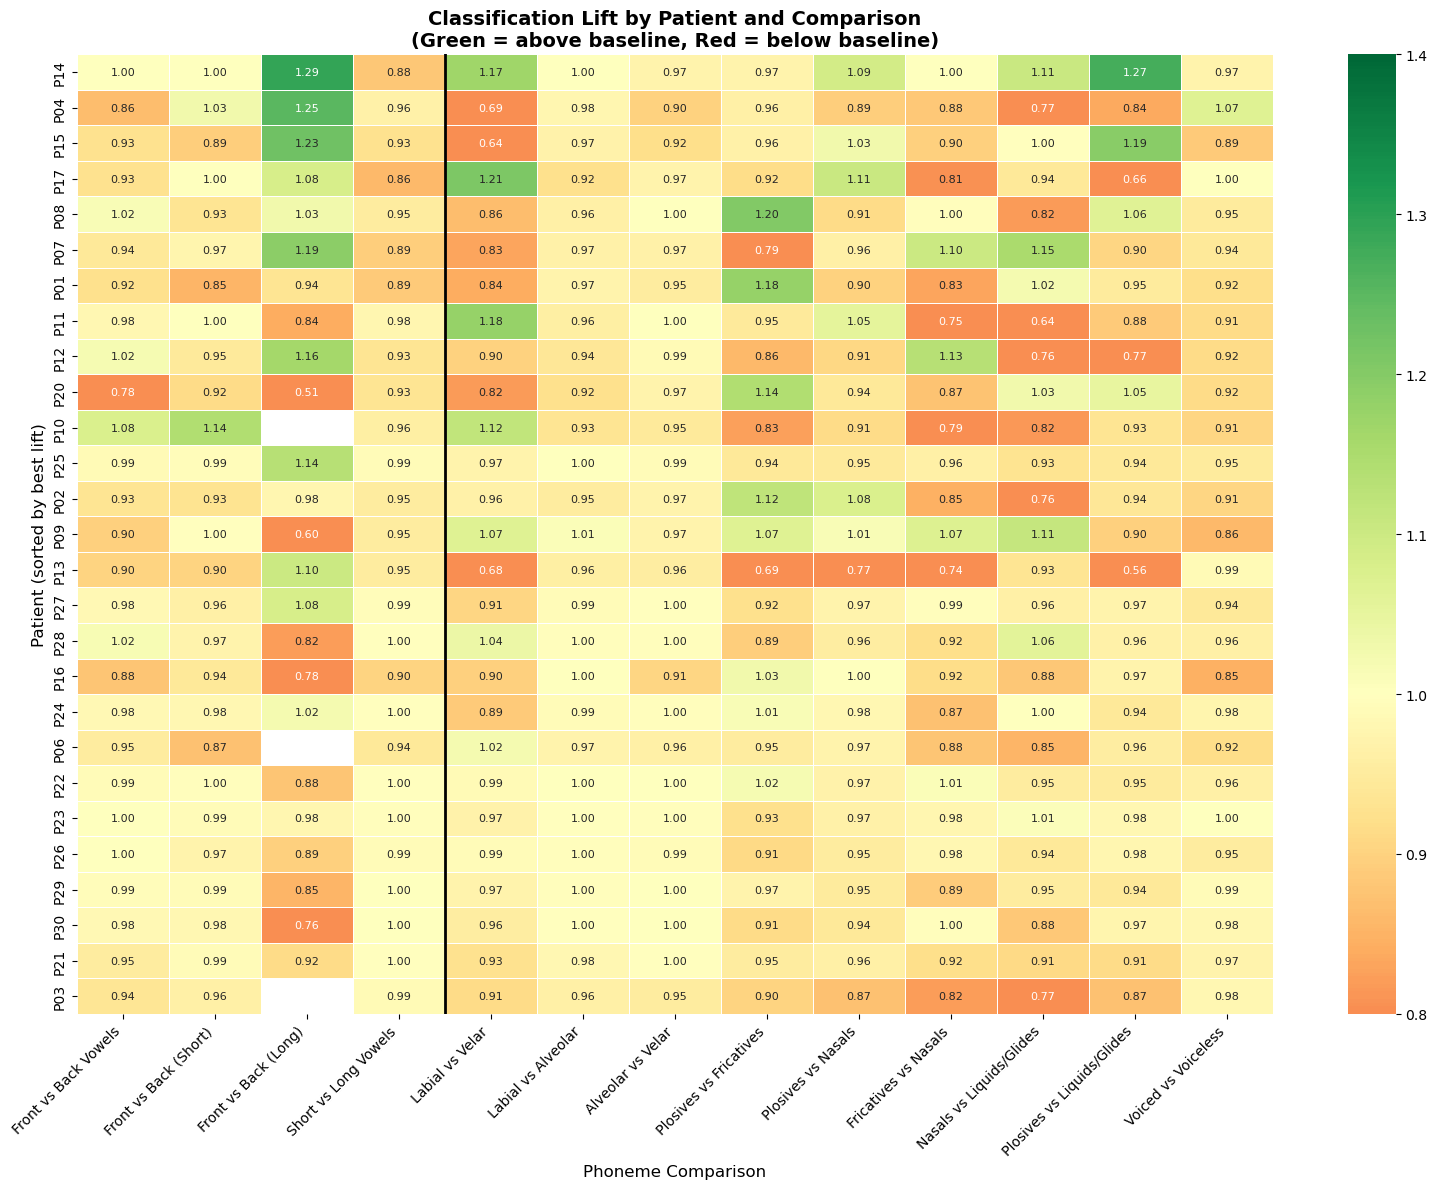

Saved: heatmap_patients_electrodes.png


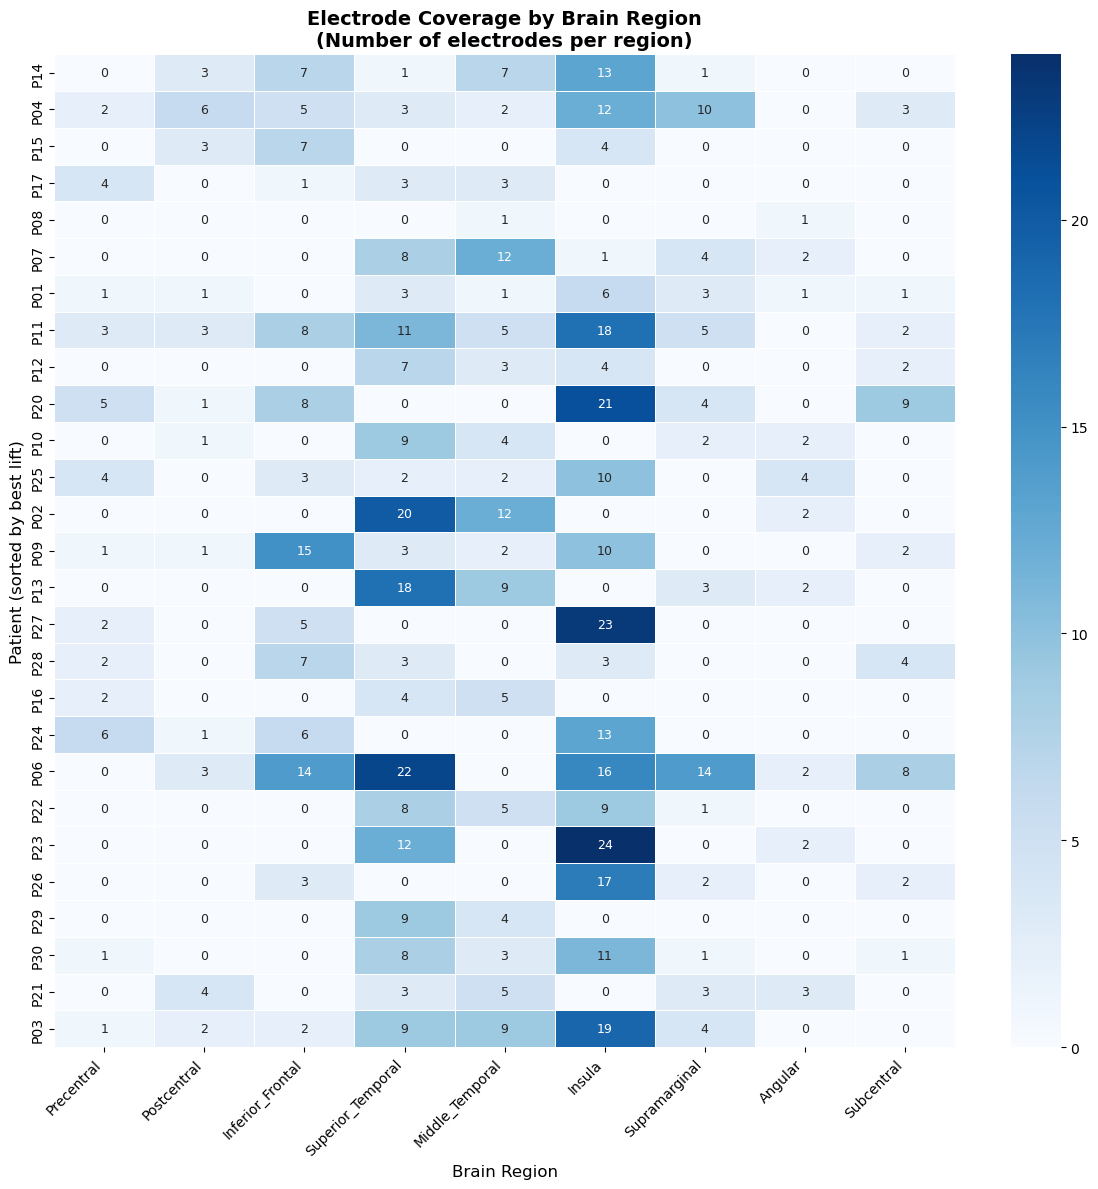

Saved: heatmap_regions_comparisons.png


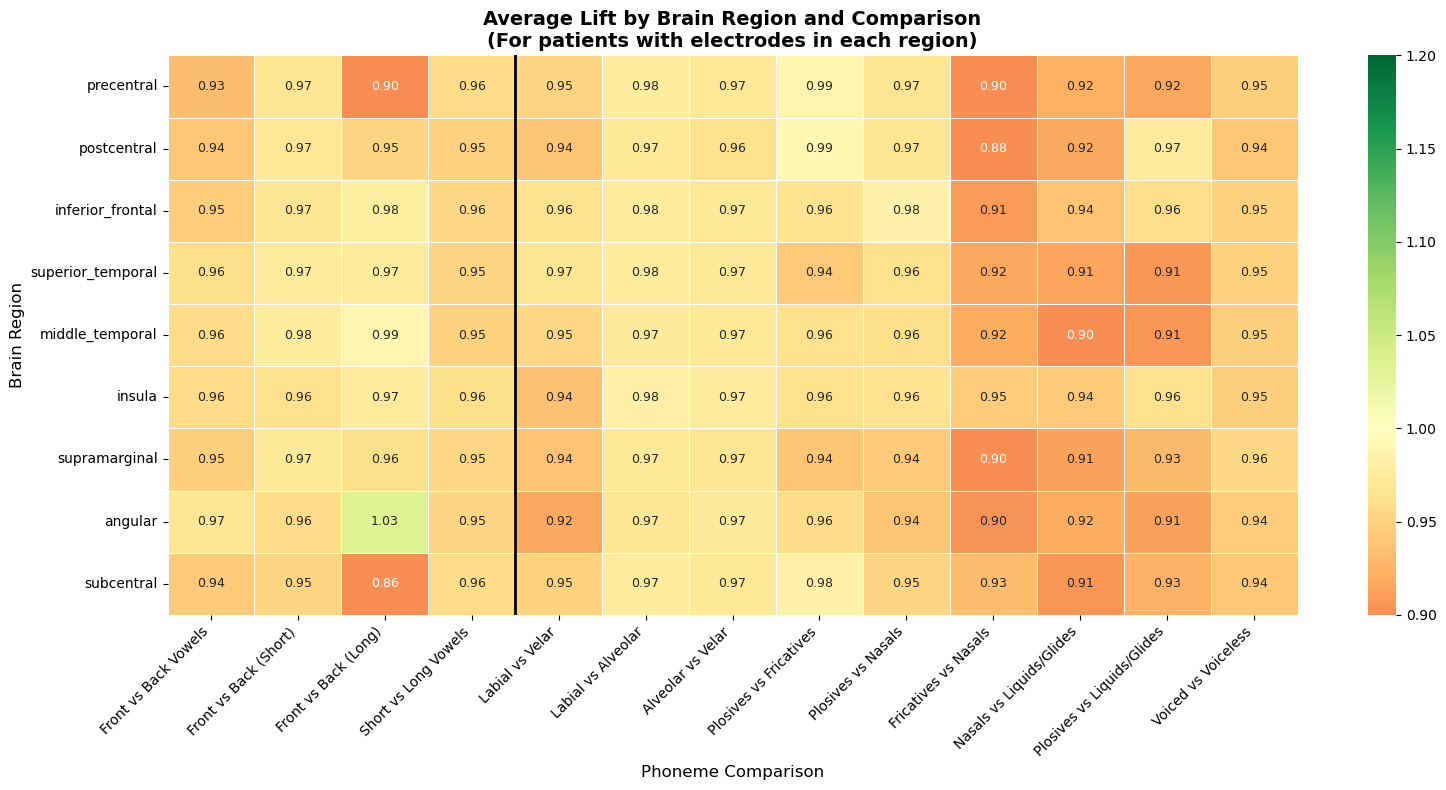

Saved: heatmap_summary.png


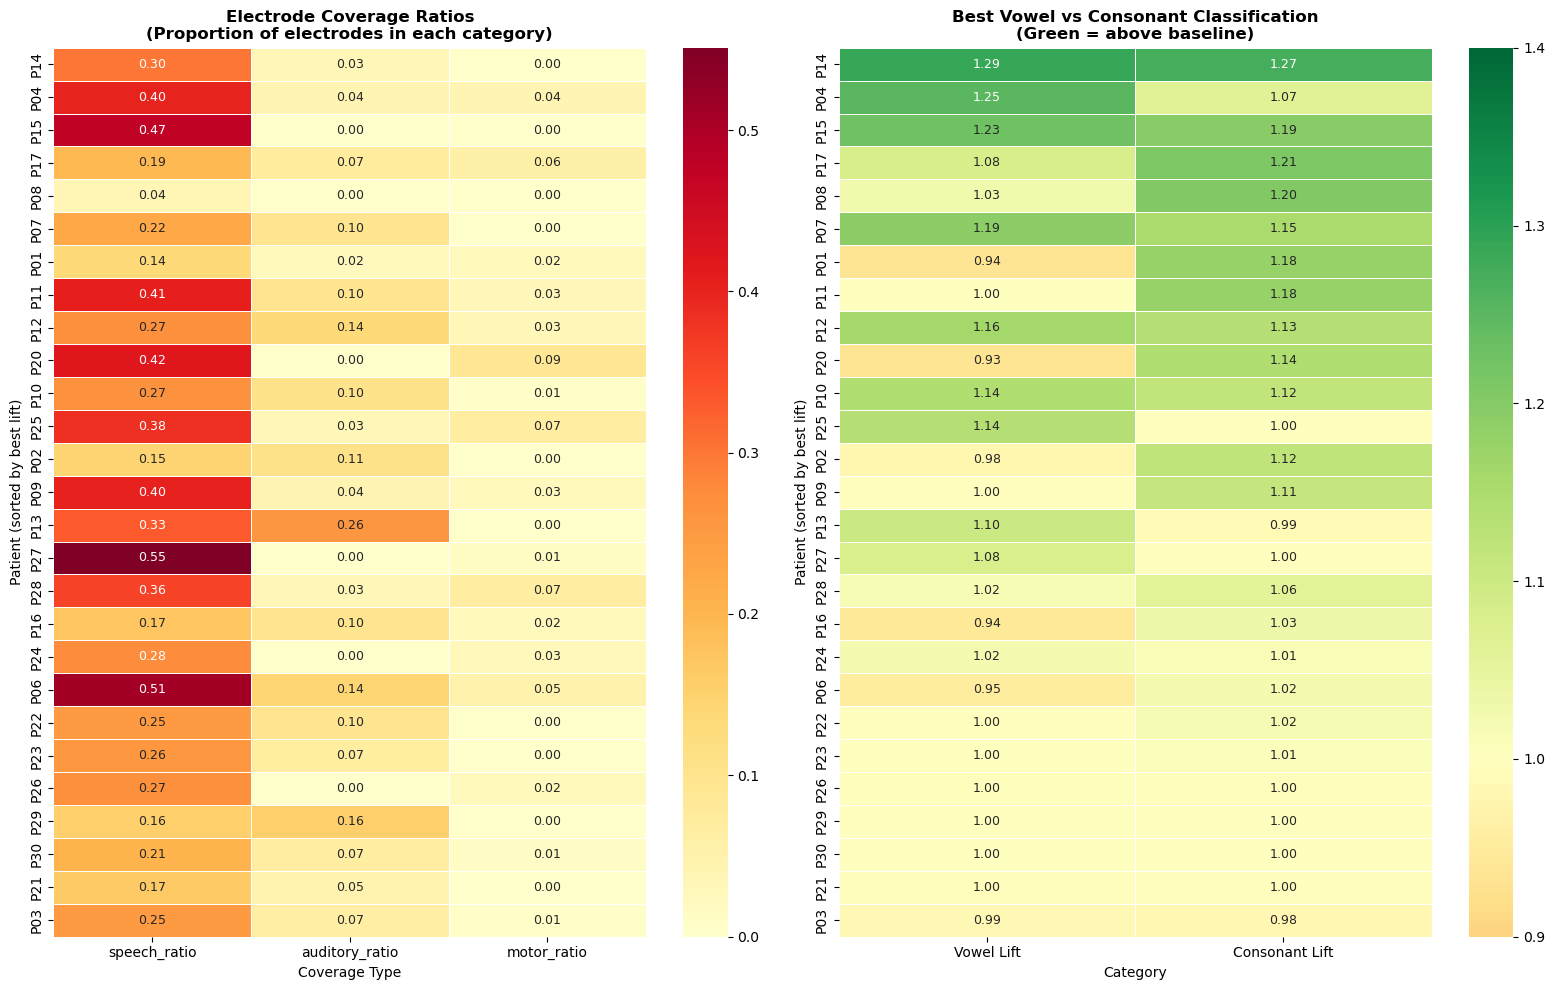

In [62]:
import os
import pandas as pd
import numpy as np
from config import DUTCH_30_PATH


def analyze_electrode_locations_all_patients(data_dir, patient_ids, results_df=None):
    """
    Analyze electrode locations for all patients with full region breakdown.
    
    Args:
        data_dir: Path to data directory with electrode CSVs
        patient_ids: List of patient IDs
        results_df: Optional DataFrame from summarize_all_patients['all_results']
    
    Returns:
        DataFrame with electrode analysis per patient
    """
    
    # Region patterns to search for in location strings (FreeSurfer Destrieux atlas)
    SPEECH_REGIONS_UPDATED = {
        'precentral': ['G_precentral', 'S_precentral-inf', 'S_precentral-sup'],
        'postcentral': ['G_postcentral', 'S_postcentral'],
        'inferior_frontal': ['G_front_inf-Opercular', 'G_front_inf-Triangul', 'G_front_inf-Orbital', 'S_front_inf'],
        'superior_frontal': ['G_front_sup', 'S_front_sup', 'G_front_middle', 'S_front_middle'],
        'superior_temporal': ['S_temporal_sup', 'G_temp_sup-Lateral', 'G_temp_sup-G_T_transv', 'G_temp_sup-Plan_tempo', 'G_temp_sup-Plan_polar'],
        'middle_temporal': ['G_temporal_middle', 'G_temporal_inf', 'S_temporal_inf'],
        'insula': ['G_Ins_lg_and_S_cent_ins', 'G_insular_short', 'S_circular_insula_sup', 'S_circular_insula_inf', 'S_circular_insula_ant'],
        'supramarginal': ['G_pariet_inf-Supramar'],
        'angular': ['G_pariet_inf-Angular'],
        'subcentral': ['G_and_S_subcentral'],
        'cingulate': ['G_and_S_cingul-Ant', 'G_and_S_cingul-Mid-Ant', 'G_and_S_cingul-Mid-Post'],
    }
    
    MOTOR_PATTERNS = ['G_precentral', 'S_precentral', 'G_and_S_subcentral', 'G_and_S_paracentral']
    AUDITORY_PATTERNS = ['G_temp_sup', 'S_temporal_sup', 'G_T_transv', 'Plan_tempo', 'G_temporal_middle']
    
    results_list = []
    
    for pid in patient_ids:
        try:
            df = pd.read_csv(os.path.join(data_dir, f'{pid}_electrode_locations.csv'))
            locations = df['location'].astype(str).tolist()
            total = len(locations)
            
            # Count per region with updated patterns
            region_counts = {}
            total_speech = 0
            
            for region, patterns in SPEECH_REGIONS_UPDATED.items():
                count = sum(1 for loc in locations if any(p in loc for p in patterns))
                region_counts[f'speech_{region}'] = count
                total_speech += count
            
            # Count category totals
            motor_total = sum(1 for loc in locations if any(p in loc for p in MOTOR_PATTERNS))
            auditory_total = sum(1 for loc in locations if any(p in loc for p in AUDITORY_PATTERNS))
            
            # Count white matter and subcortical
            white_matter = sum(1 for loc in locations if 'White-Matter' in loc)
            subcortical = sum(1 for loc in locations if any(x in loc for x in ['Hippocampus', 'Amygdala', 'Putamen', 'Caudate', 'Pallidum']))
            unknown = sum(1 for loc in locations if loc == 'Unknown')
            
            row = {
                'patient': pid,
                'total_electrodes': total,
                'speech_total': total_speech,
                'motor_total': motor_total,
                'auditory_total': auditory_total,
                'white_matter': white_matter,
                'subcortical': subcortical,
                'unknown': unknown,
                'speech_ratio': total_speech / total if total > 0 else 0,
                'motor_ratio': motor_total / total if total > 0 else 0,
                'auditory_ratio': auditory_total / total if total > 0 else 0,
                **region_counts
            }
            
            # Add best results if results_df provided
            if results_df is not None and len(results_df) > 0:
                patient_results = results_df[results_df['patient'] == pid]
                if len(patient_results) > 0:
                    # Best overall
                    best_idx = patient_results['lift'].idxmax()
                    best = patient_results.loc[best_idx]
                    row['best_comparison'] = best['comparison']
                    row['best_lift'] = best['lift']
                    
                    # Separate vowel and consonant results
                    vowel_comps = ['Front vs Back Vowels', 'Short vs Long Vowels', 
                                   'Front vs Back (Short)', 'Front vs Back (Long)']
                    
                    vowel_results = patient_results[patient_results['comparison'].isin(vowel_comps)]
                    cons_results = patient_results[~patient_results['comparison'].isin(vowel_comps)]
                    
                    if len(vowel_results) > 0:
                        row['best_vowel_lift'] = vowel_results['lift'].max()
                    else:
                        row['best_vowel_lift'] = np.nan
                        
                    if len(cons_results) > 0:
                        row['best_cons_lift'] = cons_results['lift'].max()
                    else:
                        row['best_cons_lift'] = np.nan
                    
                    # Determine if patient is better at vowels or consonants
                    if pd.notna(row.get('best_vowel_lift')) and pd.notna(row.get('best_cons_lift')):
                        row['better_at'] = 'vowels' if row['best_vowel_lift'] > row['best_cons_lift'] else 'consonants'
                    else:
                        row['better_at'] = 'unknown'
                else:
                    row['best_comparison'] = None
                    row['best_lift'] = np.nan
                    row['best_vowel_lift'] = np.nan
                    row['best_cons_lift'] = np.nan
                    row['better_at'] = 'unknown'
            else:
                row['best_comparison'] = None
                row['best_lift'] = np.nan
                row['best_vowel_lift'] = np.nan
                row['best_cons_lift'] = np.nan
                row['better_at'] = 'unknown'
            
            results_list.append(row)
            
        except Exception as e:
            print(f"Error for {pid}: {e}")
    
    return pd.DataFrame(results_list)


# Get patient IDs from your results
patient_ids = results['all_results']['patient'].unique().tolist()

# Create electrode_df with full region breakdown
data_dir = os.path.join(DUTCH_30_PATH, 'raw')

electrode_df = analyze_electrode_locations_all_patients(
    data_dir=data_dir,
    patient_ids=patient_ids,
    results_df=results['all_results']
)

print("Electrode DF columns:")
print(electrode_df.columns.tolist())

print("\nElectrode DF preview:")
print(electrode_df[['patient', 'total_electrodes', 'speech_total', 'speech_ratio', 
                    'motor_ratio', 'auditory_ratio', 'best_lift']].to_string())

print(f"\nTotal patients: {len(electrode_df)}")

# Now run heatmaps
heatmap_results = create_classification_heatmaps(
    results_df=results['all_results'],
    electrode_df=electrode_df,
    save_path='./results/heatmaps'
)

In [63]:
results = summarize_all_patients(
    high_gamma_pipeline, 
    patient_ids=['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 
                   'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 
                   'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30'],
    save_path='./results/summary'
)


Processing P01...

Processing P02...

Processing P03...

Processing P04...

Processing P06...

Processing P07...

Processing P08...

Processing P09...

Processing P10...

Processing P11...

Processing P12...

Processing P13...

Processing P14...

Processing P15...

Processing P16...

Processing P17...

Processing P20...

Processing P21...

Processing P22...

Processing P23...

Processing P24...

Processing P25...

Processing P26...

Processing P27...

Processing P28...

Processing P29...

Processing P30...

SUMMARY: BEST COMPARISON PER PATIENT
patient               comparison     lift  cohens_d  total_samples   best_feature
    P14     Front vs Back (Long) 1.290000  0.767457             18    line_length
    P04     Front vs Back (Long) 1.250000  0.556349             15            min
    P15     Front vs Back (Long) 1.225000  1.038764             14          range
    P17          Labial vs Velar 1.211594  0.802703             44    peak_to_rms
    P08   Plosives vs Fricatives 1.2040

Saved: heatmap_patients_comparisons.png


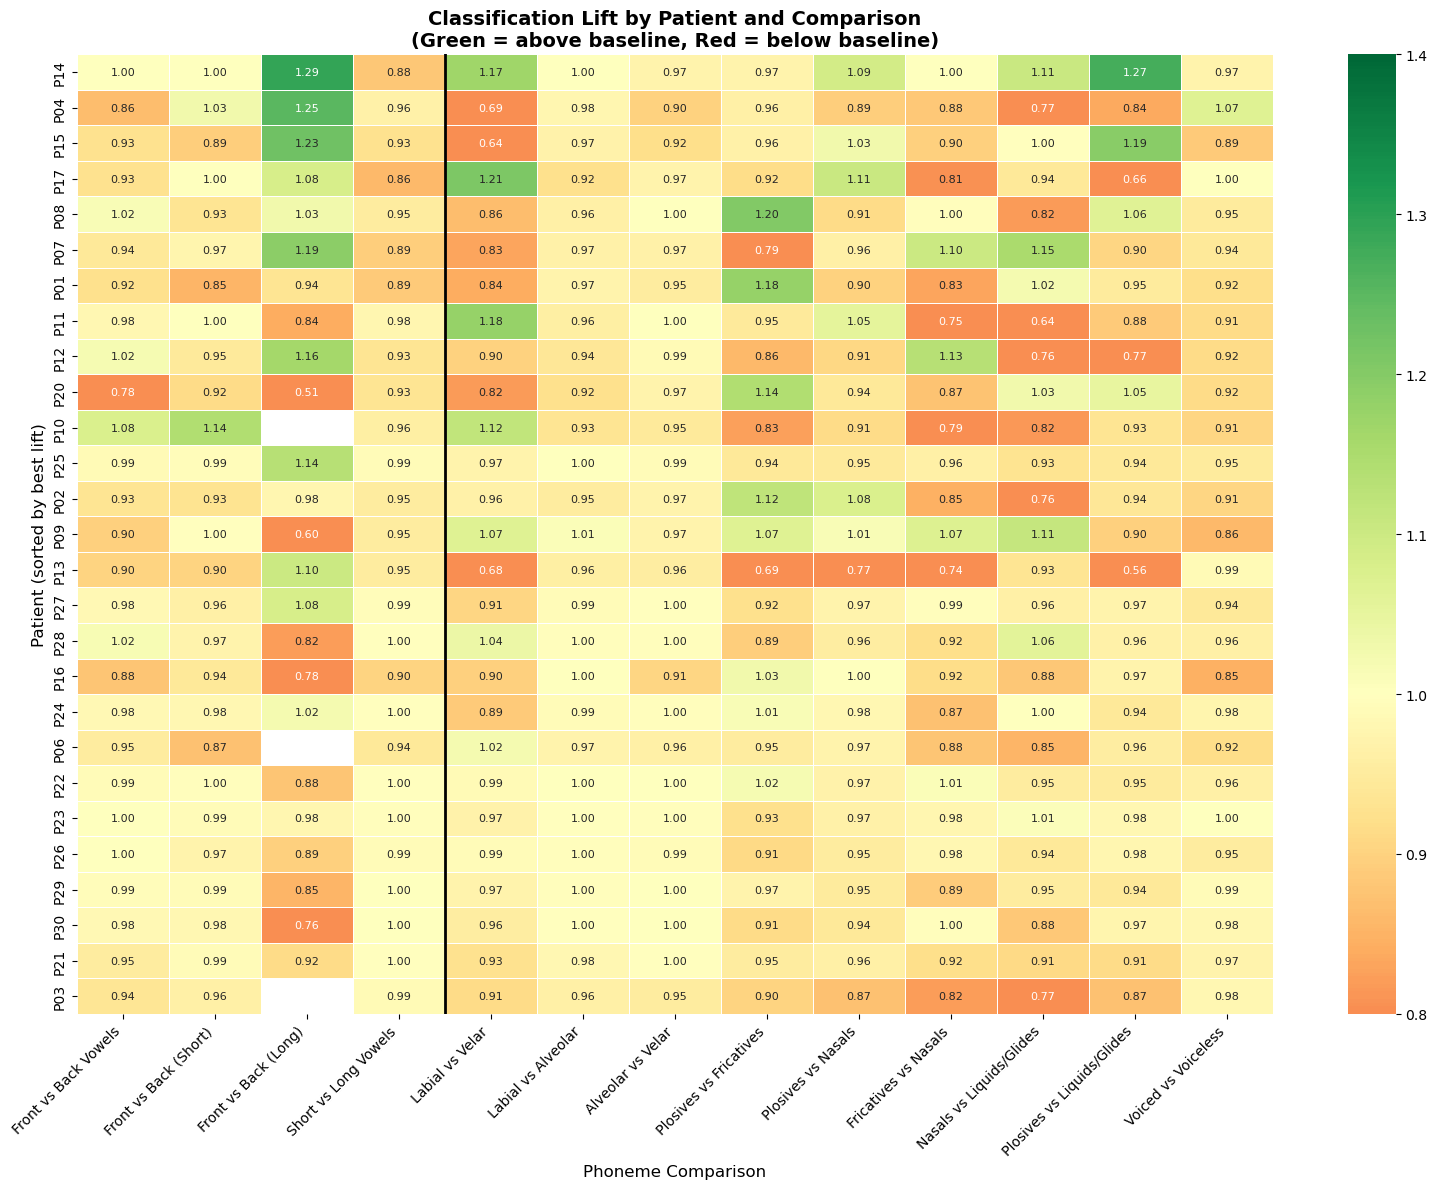

Saved: heatmap_patients_electrodes.png


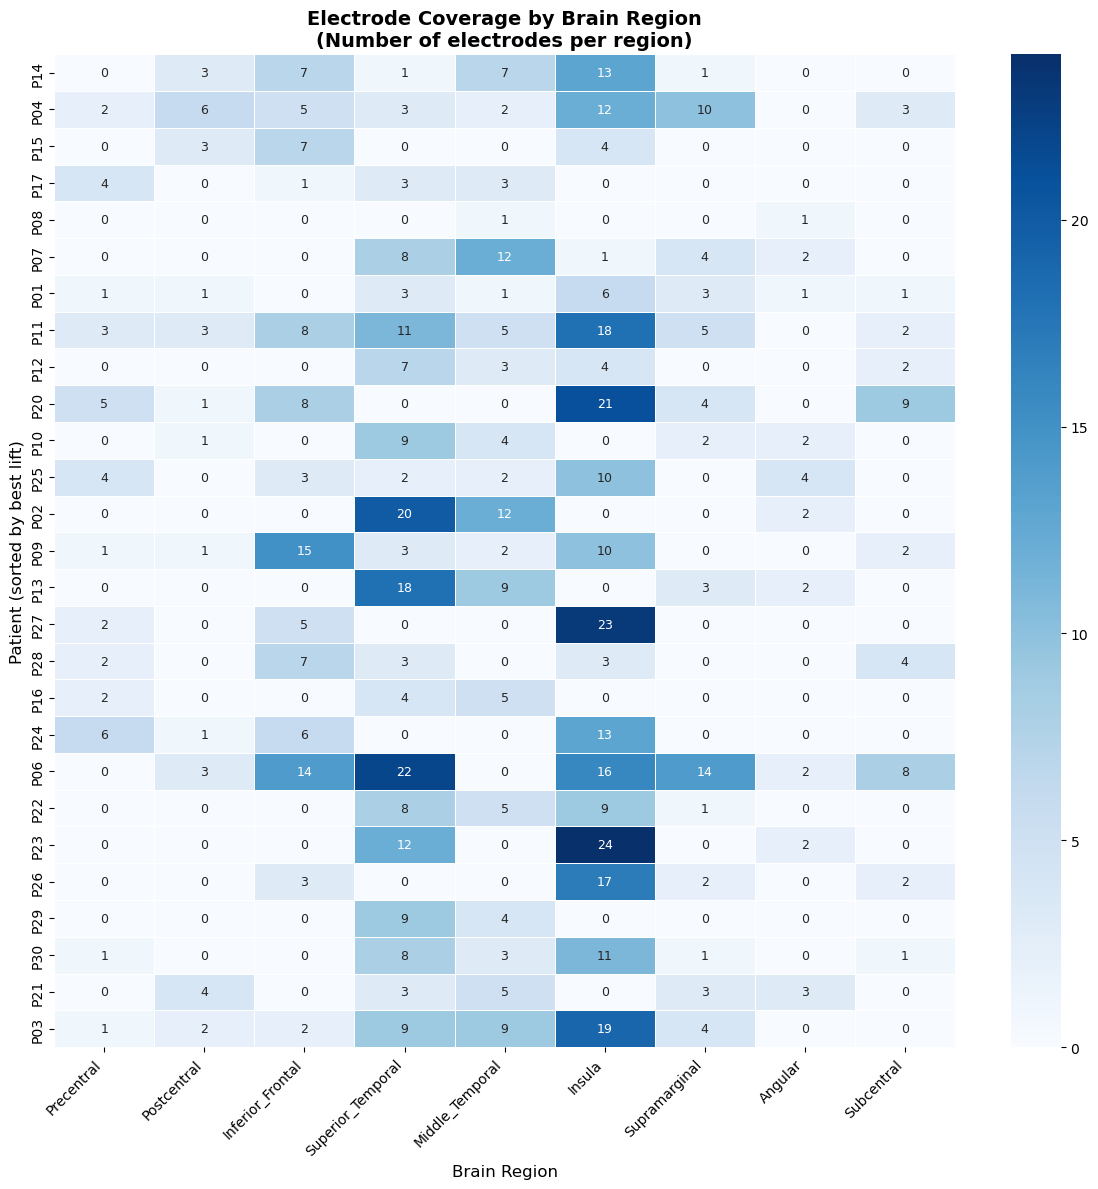

Saved: heatmap_regions_comparisons.png


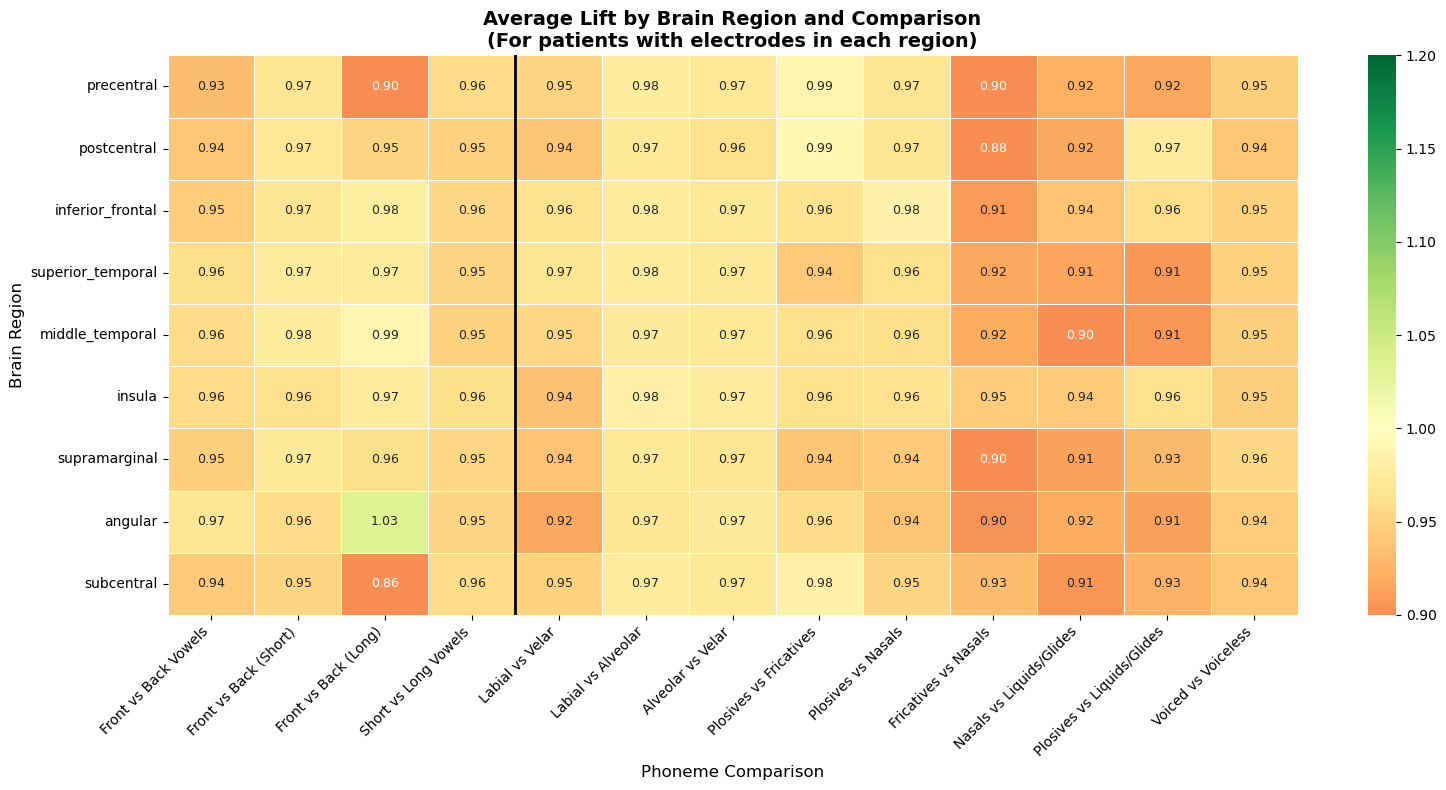

Saved: heatmap_summary.png


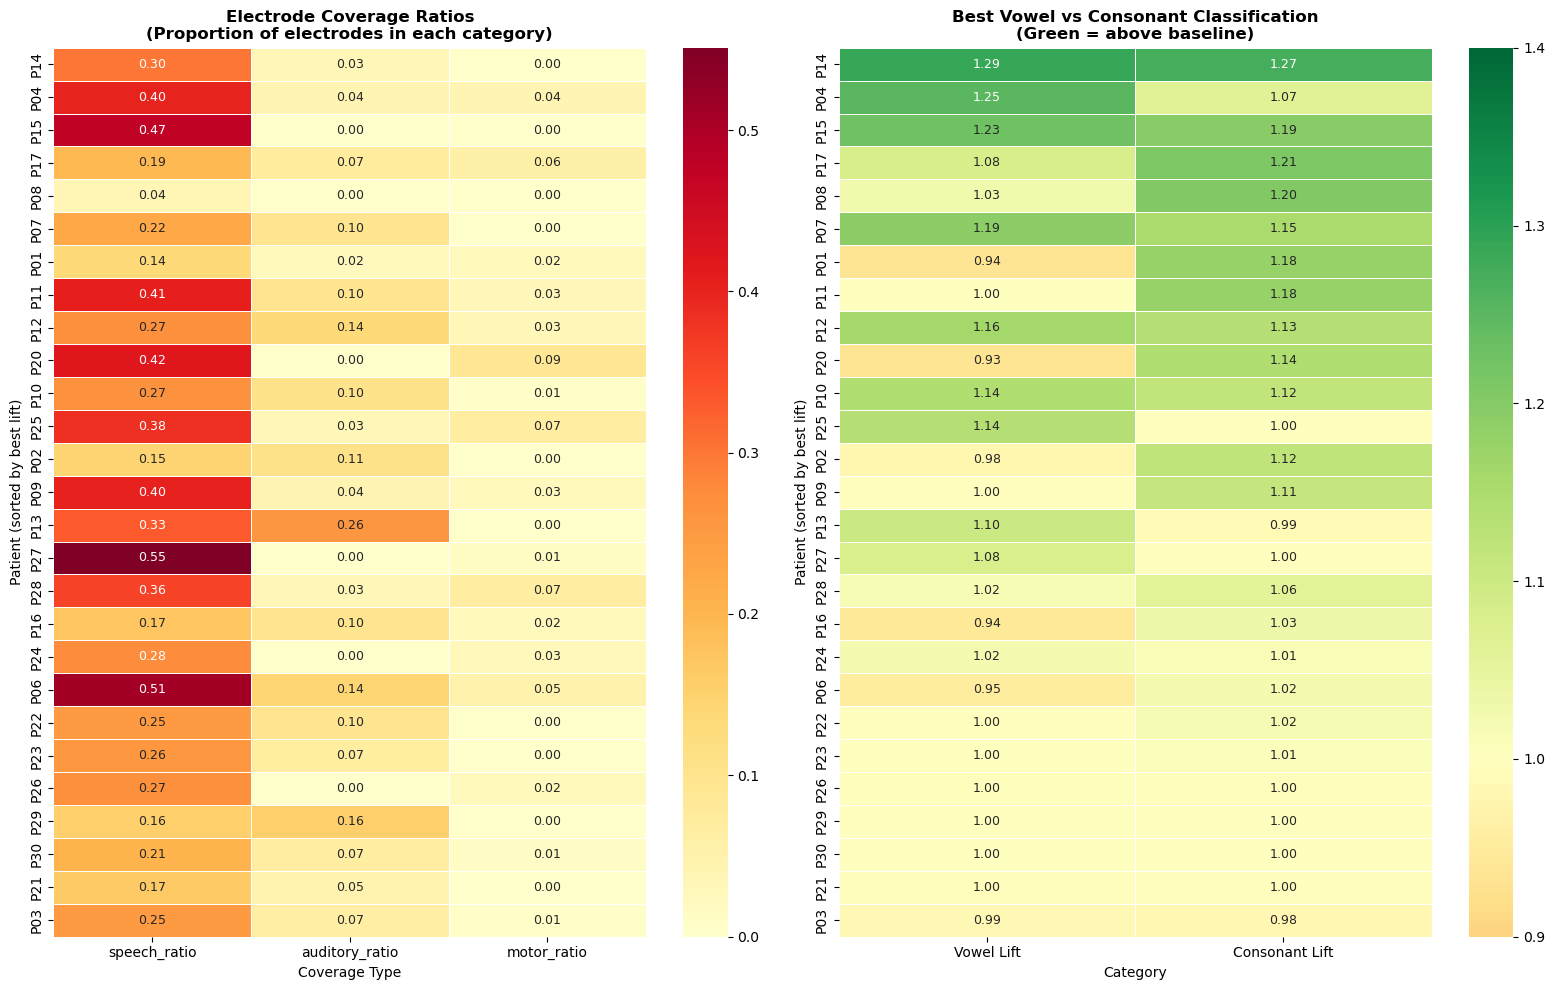

In [64]:
heatmap_results = create_classification_heatmaps(
    results_df=results['all_results'],
    electrode_df=electrode_df,
    save_path='./results/heatmaps'
)

In [51]:
# Get top 5 patients per comparison
print("=" * 70)
print("TOP 5 PATIENTS PER COMPARISON - What regions do they have?")
print("=" * 70)

region_cols = [c.replace('speech_', '') for c in electrode_df.columns 
               if c.startswith('speech_') and c not in ['speech_total', 'speech_ratio']]

for comparison in results['all_results']['comparison'].unique():
    comp_data = results['all_results'][results['all_results']['comparison'] == comparison]
    top5 = comp_data.nlargest(5, 'lift')
    
    if top5['lift'].iloc[0] < 1.05:  # Skip if best isn't even good
        continue
    
    print(f"\n{comparison} (best lift = {top5['lift'].iloc[0]:.2f}):")
    
    # For each top patient, show their electrode coverage
    for _, row in top5.iterrows():
        pid = row['patient']
        lift = row['lift']
        
        # Get electrode info
        elec_row = electrode_df[electrode_df['patient'] == pid].iloc[0]
        
        # Find regions with electrodes > 0
        regions_with_electrodes = []
        for col in electrode_df.columns:
            if col.startswith('speech_') and col not in ['speech_total', 'speech_ratio']:
                if elec_row[col] > 0:
                    regions_with_electrodes.append(f"{col.replace('speech_', '')}({int(elec_row[col])})")
        
        print(f"  {pid} (lift={lift:.2f}): {', '.join(regions_with_electrodes)}")

TOP 5 PATIENTS PER COMPARISON - What regions do they have?

Front vs Back Vowels (best lift = 1.08):
  P10 (lift=1.08): postcentral(1), superior_temporal(9), middle_temporal(4), supramarginal(2), angular(2)
  P12 (lift=1.02): superior_temporal(7), middle_temporal(1), insula(4), subcentral(2)
  P28 (lift=1.02): precentral(2), inferior_frontal(7), superior_temporal(3), insula(3), subcentral(4)
  P08 (lift=1.02): angular(1)
  P26 (lift=1.00): inferior_frontal(3), insula(17), supramarginal(2), subcentral(2)

Front vs Back (Short) (best lift = 1.14):
  P10 (lift=1.14): postcentral(1), superior_temporal(9), middle_temporal(4), supramarginal(2), angular(2)
  P04 (lift=1.03): precentral(2), postcentral(6), inferior_frontal(5), superior_temporal(3), middle_temporal(2), insula(12), supramarginal(10), subcentral(3)
  P11 (lift=1.00): precentral(3), postcentral(3), inferior_frontal(8), superior_temporal(11), middle_temporal(4), insula(18), supramarginal(5), subcentral(2)
  P14 (lift=1.00): postcen

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')


def quick_test_single_patient(pipeline, patient_id='P16'):
    """
    Quick test for a single patient to verify the pipeline works.
    """
    print(f"=== QUICK TEST: {patient_id} ===\n")
    
    train_data = pipeline.train
    test_data = pipeline.test
    
    # Get indices
    train_idx = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == patient_id]
    test_idx = [i for i, p in enumerate(test_data['phoneme_participant_ids']) if p == patient_id]
    
    print(f"Found {len(train_idx)} train, {len(test_idx)} test samples")
    
    if len(train_idx) == 0:
        print("No data found for this patient!")
        return None
    
    # Extract features (EEG only, mean over time)
    print("Extracting features...")
    
    X_train_list = []
    y_train_list = []
    
    for i in train_idx:
        label = train_data['phoneme_labels'][i]
        if label == '?':
            continue
        eeg = train_data['features'][i]
        feat = eeg.mean(axis=0)
        X_train_list.append(feat)
        y_train_list.append(label)
    
    X_test_list = []
    y_test_list = []
    
    for i in test_idx:
        label = test_data['phoneme_labels'][i]
        if label == '?':
            continue
        eeg = test_data['features'][i]
        feat = eeg.mean(axis=0)
        X_test_list.append(feat)
        y_test_list.append(label)
    
    X_train = np.array(X_train_list)
    y_train = np.array(y_train_list)
    X_test = np.array(X_test_list)
    y_test = np.array(y_test_list)
    
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"Unique train labels: {len(set(y_train))}")
    
    # Check for NaN/Inf
    print(f"NaN in X_train: {np.isnan(X_train).sum()}")
    print(f"Inf in X_train: {np.isinf(X_train).sum()}")
    
    # Filter to common phonemes
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    
    valid_phonemes = [p for p, c in train_counts.items() if c >= 5 and test_counts.get(p, 0) >= 2]
    print(f"Valid phonemes: {len(valid_phonemes)}")
    
    if len(valid_phonemes) < 2:
        print("Not enough valid phonemes")
        return None
    
    train_mask = np.isin(y_train, valid_phonemes)
    test_mask = np.isin(y_test, valid_phonemes)
    
    X_train_f = X_train[train_mask]
    y_train_f = y_train[train_mask]
    X_test_f = X_test[test_mask]
    y_test_f = y_test[test_mask]
    
    print(f"Filtered: {len(y_train_f)} train, {len(y_test_f)} test")
    
    # Scale
    print("Scaling...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_f)
    X_test_scaled = scaler.transform(X_test_f)
    
    # Check scaled data
    print(f"X_train_scaled stats: min={X_train_scaled.min():.2f}, max={X_train_scaled.max():.2f}, mean={X_train_scaled.mean():.2f}")
    
    # Train with solver that handles high-dim better
    print("Training classifier...")
    
    clf = LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        C=0.1,
        solver='saga',  # Better for high-dim
        tol=1e-3,  # Looser tolerance for faster convergence
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    clf.fit(X_train_scaled, y_train_f)
    print("Training complete!")
    
    # Evaluate
    train_pred = clf.predict(X_train_scaled)
    test_pred = clf.predict(X_test_scaled)
    
    train_acc = balanced_accuracy_score(y_train_f, train_pred)
    test_acc = balanced_accuracy_score(y_test_f, test_pred)
    
    baseline = 1 / len(valid_phonemes)
    
    print(f"\n=== RESULTS ===")
    print(f"Baseline: {baseline:.3f}")
    print(f"Train BalAcc: {train_acc:.3f} ({train_acc/baseline:.2f}x)")
    print(f"Test BalAcc: {test_acc:.3f} ({test_acc/baseline:.2f}x)")
    
    # Now test vowel/consonant grouping
    print(f"\n=== VOWEL/CONSONANT TEST ===")
    
    vowels = {'a', 'ɑ', 'e', 'ɛ', 'i', 'ɪ', 'o', 'ɔ', 'u', 'ʊ', 'y', 'ʏ', 'ø', 'œ', 'ə',
              'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɛː', 'ɔː', 'ɑː', 'ɛi', 'œy', 'ɑu'}
    
    def is_vowel(p):
        return p in vowels or p.replace('ː', '') in vowels
    
    y_train_vc = np.array(['V' if is_vowel(p) else 'C' for p in y_train])
    y_test_vc = np.array(['V' if is_vowel(p) else 'C' for p in y_test])
    
    print(f"Train distribution: {Counter(y_train_vc)}")
    print(f"Test distribution: {Counter(y_test_vc)}")
    
    # Scale all data (not just filtered)
    X_train_scaled_all = scaler.fit_transform(X_train)
    X_test_scaled_all = scaler.transform(X_test)
    
    clf_vc = LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        C=0.1,
        solver='saga',
        tol=1e-3,
        random_state=42
    )
    
    clf_vc.fit(X_train_scaled_all, y_train_vc)
    
    vc_train_acc = balanced_accuracy_score(y_train_vc, clf_vc.predict(X_train_scaled_all))
    vc_test_acc = balanced_accuracy_score(y_test_vc, clf_vc.predict(X_test_scaled_all))
    
    print(f"V/C Train BalAcc: {vc_train_acc:.3f} ({vc_train_acc/0.5:.2f}x)")
    print(f"V/C Test BalAcc: {vc_test_acc:.3f} ({vc_test_acc/0.5:.2f}x)")
    
    return {
        'patient_id': patient_id,
        'individual_test_acc': test_acc,
        'individual_lift': test_acc / baseline,
        'vc_test_acc': vc_test_acc,
        'vc_lift': vc_test_acc / 0.5
    }

In [ ]:
# Run quick test
result = quick_test_single_patient(high_gamma_pipeline, patient_id='P16')

In [ ]:
# Usage:
results_df, grouping_lifts = run_all_patients(high_gamma_pipeline)

FEATURE QUALITY EVALUATION

--- Basic Stats ---
Total samples: 14149
Unique phonemes: 48
Unique patients: 11
Unique feature shapes: 10
Time frames: min=4, max=4, unique=1
Channels: min=30, max=126, unique=10

--- Per-Patient Classification Test ---

Patient    Samples  Classes  Accuracy  Baseline  Lift
------------------------------------------------------------
P20            146       16  0.136     0.062     2.18x
P21           1137       33  0.121     0.030     4.00x
P22           1385       33  0.133     0.030     4.38x
P23           2060       35  0.134     0.029     4.71x
P24           1327       34  0.137     0.029     4.66x
P25           1172       33  0.132     0.030     4.36x
P26           1068       32  0.126     0.031     4.04x
P27           1327       33  0.127     0.030     4.18x
P28           1224       34  0.121     0.029     4.11x
P29           1517       34  0.133     0.029     4.51x
P30           1495       35  0.130     0.029     4.54x
------------------------------

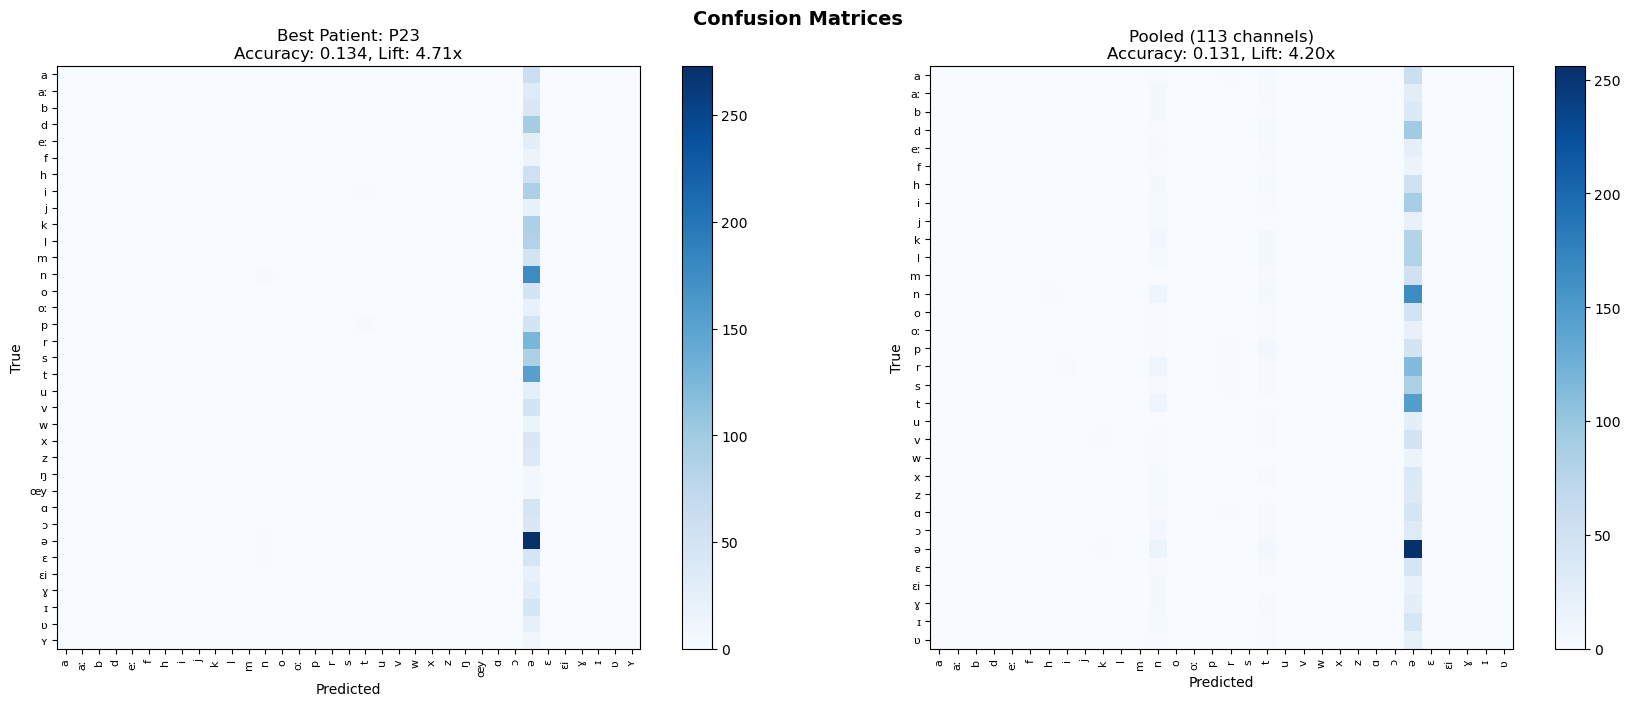

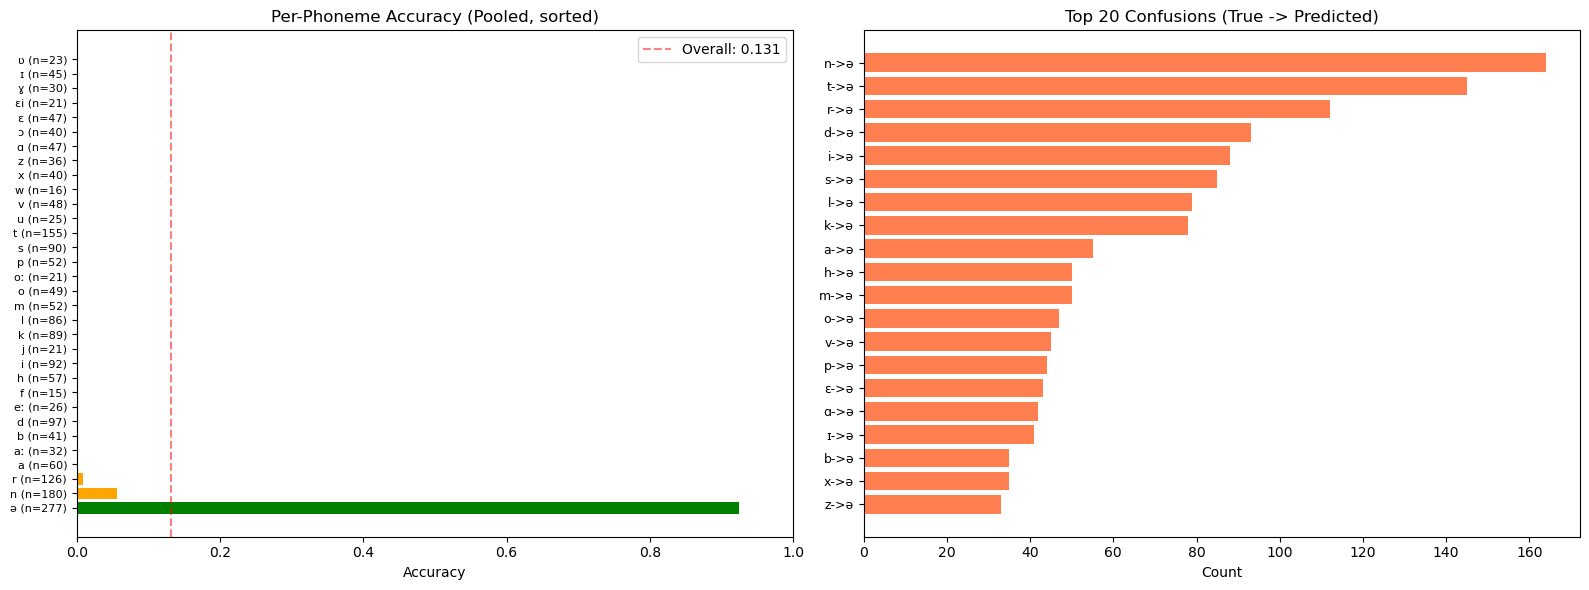


CLASSIFICATION REPORT (Pooled)
              precision    recall  f1-score   support

           a       0.00      0.00      0.00        60
          aː       0.00      0.00      0.00        32
           b       0.00      0.00      0.00        41
           d       0.00      0.00      0.00        97
          eː       0.00      0.00      0.00        26
           f       0.00      0.00      0.00        15
           h       0.00      0.00      0.00        57
           i       0.00      0.00      0.00        92
           j       0.00      0.00      0.00        21
           k       0.00      0.00      0.00        89
           l       0.00      0.00      0.00        86
           m       0.00      0.00      0.00        52
           n       0.09      0.06      0.07       180
           o       0.00      0.00      0.00        49
          oː       0.00      0.00      0.00        21
           p       0.00      0.00      0.00        52
           r       0.20      0.01      0.02      

In [58]:
def evaluate_feature_quality_v2(hg_pipeline, show_confusion=True):
    """
    Feature quality evaluation that handles variable shapes.
    
    Args:
        hg_pipeline: Pipeline with train data
        show_confusion: If True, show confusion matrix for best patient and pooled data
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import confusion_matrix, classification_report
    from collections import Counter
    
    print("="*70)
    print("FEATURE QUALITY EVALUATION")
    print("="*70)
    
    train = hg_pipeline.train
    features = train['features']
    labels = train['phoneme_labels']
    pids = train['phoneme_participant_ids']
    
    print(f"\n--- Basic Stats ---")
    print(f"Total samples: {len(features)}")
    print(f"Unique phonemes: {len(set(labels))}")
    print(f"Unique patients: {len(set(pids))}")
    
    # Check feature shapes
    shapes = [f.shape for f in features]
    unique_shapes = set(shapes)
    print(f"Unique feature shapes: {len(unique_shapes)}")
    
    # Analyze shape variation
    n_frames = [s[0] for s in shapes]
    n_channels = [s[1] for s in shapes]
    
    print(f"Time frames: min={min(n_frames)}, max={max(n_frames)}, unique={len(set(n_frames))}")
    print(f"Channels: min={min(n_channels)}, max={max(n_channels)}, unique={len(set(n_channels))}")
    
    # --- Per-Patient Analysis ---
    # print(f"\n--- Per-Patient Channel Counts ---")
    patient_channels = {}
    for pid, feat in zip(pids, features):
        if pid not in patient_channels:
            patient_channels[pid] = feat.shape[1]
    
    # for pid in sorted(patient_channels.keys())[:10]:
    #     print(f"  {pid}: {patient_channels[pid]} channels")
    # print(f"  ... ({len(patient_channels)} patients total)")
    
    # --- Evaluate per patient (same channel count) ---
    print(f"\n--- Per-Patient Classification Test ---")
    
    patient_results = {}
    patient_predictions = {}  # Store for confusion matrix
    
    for pid in sorted(set(pids)):
        # Get data for this patient
        mask = np.array([p == pid for p in pids])
        X_patient = [features[i] for i in range(len(features)) if mask[i]]
        y_patient = np.array([labels[i] for i in range(len(labels)) if mask[i]])
        
        # Average over time to get (1, n_channels) then flatten
        X_patient = np.vstack([f.mean(axis=0).reshape(1, -1) for f in X_patient])
        
        # Remove unknown labels
        valid = y_patient != '?'
        X_patient = X_patient[valid]
        y_patient = y_patient[valid]
        
        # Filter to classes with enough samples
        label_counts = Counter(y_patient)
        valid_classes = [c for c, count in label_counts.items() if count >= 5]
        
        if len(valid_classes) < 2:
            continue
        
        class_mask = np.isin(y_patient, valid_classes)
        X_filt = X_patient[class_mask]
        y_filt = y_patient[class_mask]
        
        if len(y_filt) < 20:
            continue
        
        # Scale and classify
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_filt)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
        
        n_splits = min(5, min(Counter(y_filt).values()))
        if n_splits < 2:
            continue
            
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        try:
            scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
            
            # Get predictions for confusion matrix
            y_pred = cross_val_predict(rf, X_scaled, y_filt, cv=cv)
            
            baseline = 1 / len(valid_classes)
            lift = scores.mean() / baseline
            
            patient_results[pid] = {
                'accuracy': scores.mean(),
                'baseline': baseline,
                'lift': lift,
                'n_samples': len(y_filt),
                'n_classes': len(valid_classes)
            }
            
            patient_predictions[pid] = {
                'y_true': y_filt,
                'y_pred': y_pred,
                'classes': valid_classes
            }
        except:
            continue
    
    # Print results
    print(f"\nPatient    Samples  Classes  Accuracy  Baseline  Lift")
    print("-" * 60)
    
    for pid in sorted(patient_results.keys()):
        r = patient_results[pid]
        print(f"{pid:10} {r['n_samples']:7}  {r['n_classes']:7}  {r['accuracy']:.3f}     {r['baseline']:.3f}     {r['lift']:.2f}x")
    
    # Summary
    if patient_results:
        avg_lift = np.mean([r['lift'] for r in patient_results.values()])
        avg_acc = np.mean([r['accuracy'] for r in patient_results.values()])
        print("-" * 60)
        print(f"{'Average':10} {'-':>7}  {'-':>7}  {avg_acc:.3f}     {'-':>5}     {avg_lift:.2f}x")
    
    # Find best patient
    best_pid = max(patient_results.keys(), key=lambda p: patient_results[p]['lift'])
    print(f"\nBest patient: {best_pid} (lift: {patient_results[best_pid]['lift']:.2f}x)")
    
    # --- Fixed-size feature test ---
    print(f"\n--- Testing with Summary Features (time-averaged) ---")
    
    # Group by channel count
    channel_groups = {}
    for i, (feat, label) in enumerate(zip(features, labels)):
        n_ch = feat.shape[1]
        if n_ch not in channel_groups:
            channel_groups[n_ch] = {'X': [], 'y': []}
        channel_groups[n_ch]['X'].append(feat.mean(axis=0))
        channel_groups[n_ch]['y'].append(label)
    
    print(f"\nChannel groups: {sorted(channel_groups.keys())}")
    
    # Test largest group
    largest_group = max(channel_groups.keys(), key=lambda k: len(channel_groups[k]['y']))
    X_largest = np.vstack(channel_groups[largest_group]['X'])
    y_largest = np.array(channel_groups[largest_group]['y'])
    
    # Filter
    valid = y_largest != '?'
    X_largest = X_largest[valid]
    y_largest = y_largest[valid]
    
    label_counts = Counter(y_largest)
    valid_classes = [c for c, count in label_counts.items() if count >= 10]
    class_mask = np.isin(y_largest, valid_classes)
    X_filt = X_largest[class_mask]
    y_filt = y_largest[class_mask]
    
    print(f"Largest channel group ({largest_group} channels): {len(y_filt)} samples, {len(valid_classes)} classes")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filt)
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
    
    # Get predictions for pooled confusion matrix
    y_pred_pooled = cross_val_predict(rf, X_scaled, y_filt, cv=cv)
    
    baseline = 1 / len(valid_classes)
    
    print(f"5-fold CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"Random baseline: {baseline:.3f}")
    print(f"Lift over baseline: {scores.mean() / baseline:.2f}x")
    
    # --- Confusion Matrices ---
    if show_confusion:
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
        
        # 1. Best patient confusion matrix
        best_data = patient_predictions[best_pid]
        y_true_best = best_data['y_true']
        y_pred_best = best_data['y_pred']
        classes_best = sorted(set(y_true_best) | set(y_pred_best))
        
        cm_best = confusion_matrix(y_true_best, y_pred_best, labels=classes_best)
        
        im1 = axes[0].imshow(cm_best, cmap='Blues')
        axes[0].set_xticks(range(len(classes_best)))
        axes[0].set_yticks(range(len(classes_best)))
        axes[0].set_xticklabels(classes_best, rotation=90, fontsize=8)
        axes[0].set_yticklabels(classes_best, fontsize=8)
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')
        axes[0].set_title(f'Best Patient: {best_pid}\nAccuracy: {patient_results[best_pid]["accuracy"]:.3f}, Lift: {patient_results[best_pid]["lift"]:.2f}x')
        plt.colorbar(im1, ax=axes[0])
        
        # 2. Pooled confusion matrix (largest channel group)
        classes_pooled = sorted(set(y_filt) | set(y_pred_pooled))
        cm_pooled = confusion_matrix(y_filt, y_pred_pooled, labels=classes_pooled)
        
        im2 = axes[1].imshow(cm_pooled, cmap='Blues')
        axes[1].set_xticks(range(len(classes_pooled)))
        axes[1].set_yticks(range(len(classes_pooled)))
        axes[1].set_xticklabels(classes_pooled, rotation=90, fontsize=8)
        axes[1].set_yticklabels(classes_pooled, fontsize=8)
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        axes[1].set_title(f'Pooled ({largest_group} channels)\nAccuracy: {scores.mean():.3f}, Lift: {scores.mean()/baseline:.2f}x')
        plt.colorbar(im2, ax=axes[1])
        
        plt.tight_layout()
        plt.show()
        
        # Per-phoneme accuracy for pooled data
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Calculate per-phoneme accuracy
        phoneme_acc = {}
        phoneme_counts = Counter(y_filt)
        
        for p in classes_pooled:
            correct = sum(1 for t, pred in zip(y_filt, y_pred_pooled) if t == p and pred == p)
            total = phoneme_counts.get(p, 0)
            phoneme_acc[p] = correct / total if total > 0 else 0
        
        # Sort by accuracy
        sorted_phonemes = sorted(phoneme_acc.keys(), key=lambda x: phoneme_acc[x], reverse=True)
        
        colors = ['green' if phoneme_acc[p] > scores.mean() else 'orange' if phoneme_acc[p] > 0 else 'red' 
                  for p in sorted_phonemes]
        
        axes[0].barh(range(len(sorted_phonemes)), [phoneme_acc[p] for p in sorted_phonemes], color=colors)
        axes[0].set_yticks(range(len(sorted_phonemes)))
        axes[0].set_yticklabels([f"{p} (n={phoneme_counts[p]})" for p in sorted_phonemes], fontsize=8)
        axes[0].set_xlabel('Accuracy')
        axes[0].set_title('Per-Phoneme Accuracy (Pooled, sorted)')
        axes[0].axvline(scores.mean(), color='red', linestyle='--', alpha=0.5, label=f'Overall: {scores.mean():.3f}')
        axes[0].legend()
        axes[0].set_xlim([0, 1])
        
        # Top confusions
        confusion_pairs = []
        for i, true_label in enumerate(classes_pooled):
            for j, pred_label in enumerate(classes_pooled):
                if true_label != pred_label and cm_pooled[i, j] > 0:
                    confusion_pairs.append((true_label, pred_label, cm_pooled[i, j]))
        
        confusion_pairs.sort(key=lambda x: x[2], reverse=True)
        top_confusions = confusion_pairs[:20]
        
        conf_labels = [f"{t}->{p}" for t, p, _ in top_confusions]
        conf_counts = [c for _, _, c in top_confusions]
        
        axes[1].barh(range(len(top_confusions)), conf_counts, color='coral')
        axes[1].set_yticks(range(len(top_confusions)))
        axes[1].set_yticklabels(conf_labels, fontsize=9)
        axes[1].set_xlabel('Count')
        axes[1].set_title('Top 20 Confusions (True -> Predicted)')
        axes[1].invert_yaxis()
        
        plt.tight_layout()
        plt.show()
        
        # Print classification report
        print("\n" + "="*70)
        print("CLASSIFICATION REPORT (Pooled)")
        print("="*70)
        print(classification_report(y_filt, y_pred_pooled, zero_division=0))
    
    return patient_results


# Run evaluation
results = evaluate_feature_quality_v2(high_gamma_pipeline, show_confusion=True)

In [37]:
def test_vowel_consonant(hg_pipeline):
    """Test binary vowel vs consonant classification."""
    
    vowels = {'a', 'e', 'i', 'o', 'u', 'ɑ', 'ɛ', 'ɪ', 'ɔ', 'ʏ', 'ə', 'eː', 'oː', 'aː', 'yː', 'øː', 'iː', 'uː'}
    
    train = hg_pipeline.train
    features = train['features']
    labels = train['phoneme_labels']
    pids = train['phoneme_participant_ids']
    
    # Create binary labels
    binary_labels = []
    for label in labels:
        if label == '?':
            binary_labels.append('?')
        elif label in vowels:
            binary_labels.append('vowel')
        else:
            binary_labels.append('consonant')
    
    binary_labels = np.array(binary_labels)
    
    # Group by channel count
    channel_groups = {}
    for i, (feat, label) in enumerate(zip(features, binary_labels)):
        if label == '?':
            continue
        n_ch = feat.shape[1]
        if n_ch not in channel_groups:
            channel_groups[n_ch] = {'X': [], 'y': []}
        channel_groups[n_ch]['X'].append(feat.mean(axis=0))
        channel_groups[n_ch]['y'].append(label)
    
    # Test largest group
    largest_ch = max(channel_groups.keys(), key=lambda k: len(channel_groups[k]['y']))
    X = np.vstack(channel_groups[largest_ch]['X'])
    y = np.array(channel_groups[largest_ch]['y'])
    
    print(f"Vowel vs Consonant Classification ({largest_ch} channels)")
    print(f"Samples: {len(y)} (vowels: {sum(y=='vowel')}, consonants: {sum(y=='consonant')})")
    
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
    
    print(f"5-fold CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"Random baseline: 0.500")
    print(f"Lift: {scores.mean() / 0.5:.2f}x")


test_vowel_consonant(high_gamma_pipeline)

Vowel vs Consonant Classification (130 channels)
Samples: 1415 (vowels: 546, consonants: 869)
5-fold CV accuracy: 0.611 (+/- 0.008)
Random baseline: 0.500
Lift: 1.22x


In [59]:
def test_segmentation_approaches(pipeline, patient_id='P23', n_test_words=50):
    """
    Test different phoneme segmentation approaches on one patient.
    
    Args:
        pipeline: Pipeline with loaded data (needs split_result and word_segments_dict)
        patient_id: Which patient to test
        n_test_words: Number of words to test per approach
    """
    import numpy as np
    from collections import Counter
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import StandardScaler
    
    print("="*70)
    print(f"TESTING SEGMENTATION APPROACHES - {patient_id}")
    print("="*70)
    
    # Get data for this patient
    split_result = pipeline.split_result
    word_segments_dict = split_result['word_segments_dict']
    detector = pipeline.detector
    config = pipeline.config
    
    if patient_id not in word_segments_dict:
        print(f"Patient {patient_id} not found!")
        return
    
    # Collect word instances for this patient
    instances = []
    for word, indices in split_result['train'].get(patient_id, {}).items():
        for idx in indices:
            instances.append({
                'word': word,
                'idx': idx,
                'data': word_segments_dict[patient_id]['words'][word]['instances'][idx]
            })
    
    if len(instances) < n_test_words:
        n_test_words = len(instances)
    
    print(f"Testing on {n_test_words} word instances from {patient_id}")
    print(f"Total available: {len(instances)} instances")
    
    # Define approaches to test
    approaches = {
        'raw_boundaries': {
            'description': 'Raw boundaries, no extension, no fixed window',
            'extend_short': False,
            'fixed_window': False,
            'drop_invalid': False
        },
        'extend_only': {
            'description': 'Extend short segments, no fixed window',
            'extend_short': True,
            'fixed_window': False,
            'drop_invalid': False
        },
        'fixed_window_only': {
            'description': 'No extension, fixed window (102 samples)',
            'extend_short': False,
            'fixed_window': True,
            'drop_invalid': False
        },
        'extend_and_fixed': {
            'description': 'Extend short + fixed window',
            'extend_short': True,
            'fixed_window': True,
            'drop_invalid': False
        },
        'drop_invalid': {
            'description': 'Drop segments outside [0.025, 0.4]s',
            'extend_short': False,
            'fixed_window': False,
            'drop_invalid': True
        },
        'extend_and_drop': {
            'description': 'Extend short + drop invalid words',
            'extend_short': True,
            'fixed_window': False,
            'drop_invalid': True
        }
    }
    
    results = {}
    
    for approach_name, settings in approaches.items():
        print(f"\n--- Testing: {approach_name} ---")
        print(f"    {settings['description']}")
        
        features = []
        labels = []
        dropped_words = 0
        dropped_phonemes = 0
        total_phonemes = 0
        
        for inst in instances[:n_test_words]:
            word = inst['word']
            word_data = inst['data']
            
            eeg_segment = word_data['eeg_segment']
            spec_segment = word_data['spectrogram_segment']
            audio_segment = word_data.get('audio_segment')
            
            # Get expected phonemes
            expected_phonemes = detector.phonetic_dict.extract_phonemes(word)
            if not expected_phonemes:
                continue
            
            total_phonemes += len(expected_phonemes)
            
            # Detect boundaries
            result = detector.detect_boundaries(
                spectrogram=spec_segment,
                word=word,
                participant_id=patient_id,
                word_position=0,
                use_multifeature=detector.use_multifeature,
                use_rms_boundaries=detector.use_rms_boundaries,
                audio_segment=audio_segment,
                audio_sr=config.audio_sr
            )
            
            boundary_samples = result.get('boundary_samples', [])
            segments = result.get('segments', [])
            
            # Check for segment/phoneme mismatch
            if len(segments) != len(expected_phonemes):
                dropped_words += 1
                dropped_phonemes += len(expected_phonemes)
                continue
            
            # Apply approach-specific processing
            min_samples = config.min_eeg_samples_for_features
            min_duration = config.min_phoneme_duration
            max_duration = config.max_phoneme_duration
            
            # Get segment boundaries
            if settings['extend_short']:
                seg_bounds = detector._extend_short_segments(
                    boundary_samples, 
                    eeg_segment.shape[0], 
                    min_samples
                )
            else:
                seg_bounds = [(boundary_samples[i], boundary_samples[i+1]) 
                              for i in range(len(boundary_samples)-1)]
            
            # Check durations if dropping invalid
            if settings['drop_invalid']:
                durations = [(end - start) / config.eeg_sr for start, end in seg_bounds]
                has_invalid = any(d < min_duration or d > max_duration for d in durations)
                if has_invalid:
                    dropped_words += 1
                    dropped_phonemes += len(expected_phonemes)
                    continue
            
            # Extract features for each phoneme
            word_valid = True
            word_features = []
            word_labels = []
            
            for j, (phoneme, (start, end)) in enumerate(zip(expected_phonemes, seg_bounds)):
                start = int(max(0, start))
                end = int(min(eeg_segment.shape[0], end))
                
                if start >= end:
                    word_valid = False
                    break
                
                raw_seg = eeg_segment[start:end]
                
                # Apply fixed window if requested
                if settings['fixed_window']:
                    target_samples = config.fixed_feature_samples
                    n_samples = raw_seg.shape[0]
                    
                    if n_samples > target_samples:
                        # Truncate from center
                        trim_start = (n_samples - target_samples) // 2
                        raw_seg = raw_seg[trim_start:trim_start + target_samples]
                    elif n_samples < target_samples:
                        # Pad with edge values
                        pad_total = target_samples - n_samples
                        pad_before = pad_total // 2
                        pad_after = pad_total - pad_before
                        raw_seg = np.pad(raw_seg, ((pad_before, pad_after), (0, 0)), mode='edge')
                
                # Check minimum samples for feature extraction
                if raw_seg.shape[0] < min_samples:
                    word_valid = False
                    break
                
                # Extract high gamma features
                try:
                    from extract_features import extractHG
                    feat = extractHG(raw_seg, config.eeg_sr)
                    
                    if feat.shape[0] == 0:
                        word_valid = False
                        break
                    
                    # Average over time
                    feat_avg = feat.mean(axis=0)
                    word_features.append(feat_avg)
                    word_labels.append(phoneme)
                    
                except Exception as e:
                    word_valid = False
                    break
            
            if word_valid and len(word_features) == len(expected_phonemes):
                features.extend(word_features)
                labels.extend(word_labels)
            else:
                dropped_words += 1
                dropped_phonemes += len(expected_phonemes)
        
        # Evaluate
        print(f"    Samples extracted: {len(features)}")
        print(f"    Words dropped: {dropped_words}")
        print(f"    Phonemes dropped: {dropped_phonemes}/{total_phonemes} ({100*dropped_phonemes/total_phonemes:.1f}%)")
        
        if len(features) < 20:
            print(f"    NOT ENOUGH DATA FOR CLASSIFICATION")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
            continue
        
        # Prepare for classification
        X = np.array(features)
        y = np.array(labels)
        
        # Filter to classes with enough samples
        label_counts = Counter(y)
        valid_classes = [c for c, count in label_counts.items() if count >= 3]
        
        if len(valid_classes) < 2:
            print(f"    NOT ENOUGH CLASSES")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
            continue
        
        mask = np.isin(y, valid_classes)
        X_filt = X[mask]
        y_filt = y[mask]
        
        # Scale and classify
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_filt)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        
        n_splits = min(3, min(Counter(y_filt).values()))
        if n_splits < 2:
            n_splits = 2
        
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        try:
            scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
            baseline = 1 / len(valid_classes)
            lift = scores.mean() / baseline
            
            print(f"    Classes: {len(valid_classes)}")
            print(f"    Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
            print(f"    Baseline: {baseline:.3f}")
            print(f"    Lift: {lift:.2f}x")
            
            results[approach_name] = {
                'accuracy': scores.mean(),
                'lift': lift,
                'n_samples': len(X_filt),
                'n_classes': len(valid_classes),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1,
                'baseline': baseline
            }
        except Exception as e:
            print(f"    Classification failed: {e}")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
    
    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"\n{'Approach':<20} {'Samples':<10} {'Drop%':<10} {'Classes':<10} {'Accuracy':<10} {'Lift':<10}")
    print("-"*70)
    
    for name, r in sorted(results.items(), key=lambda x: x[1].get('lift', 0), reverse=True):
        print(f"{name:<20} {r.get('n_samples', 0):<10} {r.get('drop_rate', 0)*100:<10.1f} "
              f"{r.get('n_classes', 0):<10} {r.get('accuracy', 0):<10.3f} {r.get('lift', 0):<10.2f}x")
    
    # Best approach
    best = max(results.items(), key=lambda x: x[1].get('lift', 0))
    print(f"\nBEST APPROACH: {best[0]} (lift: {best[1].get('lift', 0):.2f}x)")
    
    return results


# Run the test
results = test_segmentation_approaches(
    high_gamma_pipeline, 
    patient_id='P23',  # Best performing patient
    n_test_words=100
)

TESTING SEGMENTATION APPROACHES - P23
Testing on 100 word instances from P23
Total available: 500 instances

--- Testing: raw_boundaries ---
    Raw boundaries, no extension, no fixed window
AcousticChangeDetector:   Need 5 peaks but only found 3 for word 'huidige' (Patient P23)
AcousticChangeDetector:   Need 3 peaks but only found 2 for word 'staat' (Patient P23)
AcousticChangeDetector:   Need 4 peaks but only found 3 for word 'Zalig' (Patient P23)
    Samples extracted: 44
    Words dropped: 79
    Phonemes dropped: 235/279 (84.2%)
    Classes: 5
    Accuracy: 0.481 (+/- 0.026)
    Baseline: 0.200
    Lift: 2.41x

--- Testing: extend_only ---
    Extend short segments, no fixed window
AcousticChangeDetector:   Need 5 peaks but only found 3 for word 'huidige' (Patient P23)
AcousticChangeDetector:   Need 3 peaks but only found 2 for word 'staat' (Patient P23)
AcousticChangeDetector:   Need 4 peaks but only found 3 for word 'Zalig' (Patient P23)
    Samples extracted: 44
    Words dropp

In [24]:
def visualize_pipeline_features(pipeline, patient_id=None, save_path=None):
    """
    Visualize features already extracted by the pipeline.
    
    Includes:
    - Basic feature distributions
    - Transient/kurtosis features (computed from pipeline features)
    - Feature separability analysis
    - Phoneme heatmaps
    - Learning curves (overall and feature-specific)
    - Dendrograms
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_id: Optional - filter to specific patient, or None for all
        save_path: Directory to save figures
    
    Returns:
        dict: Analysis results
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from scipy.signal import hilbert
    from sklearn.model_selection import learning_curve, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
    from scipy.spatial.distance import pdist
    from collections import defaultdict
    import os
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get data from pipeline
    features_list = train_data['features']
    labels = train_data['phoneme_labels']
    words = train_data['phoneme_words']
    participant_ids = train_data['phoneme_participant_ids']
    
    # Filter by patient if specified
    if patient_id is not None:
        indices = [i for i, pid in enumerate(participant_ids) if pid == patient_id]
        if not indices:
            print(f"No data found for patient {patient_id}")
            return None
        features_list = [features_list[i] for i in indices]
        labels = [labels[i] for i in indices]
        words = [words[i] for i in indices]
        participant_ids = [participant_ids[i] for i in indices]
        print(f"Filtered to {len(indices)} samples for {patient_id}")
    
    print(f"Total samples: {len(features_list)}")
    print(f"Unique phonemes: {len(set(labels))}")
    print(f"Unique patients: {len(set(participant_ids))}")
    
    # Define vowels
    vowels = getattr(pipeline.config, 'vowels', None)
    if vowels is None:
        vowels = {
            # Short monophthongs
            'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
            
            # Long vowels (IPA length marker)
            'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
            
            # Long vowels (colon notation - in case your data uses this)
            'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
            
            # Diphthongs
            'ɛi', 'œy', 'ɑu', 'ʌu',
        }
    
    # ========================================================================
    # FEATURE EXTRACTION FROM PIPELINE DATA
    # ========================================================================
    
    def extract_summary_features(feat):
        """
        Extract summary statistics from pipeline feature matrix.
        
        Args:
            feat: numpy array - can be (n_frames, n_channels) or (1, n_features)
        
        Returns:
            dict: Summary features including transient-like measures
        """
        if feat is None or feat.size == 0:
            return None
        
        # Handle different input shapes
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        
        summary = {}
        
        # If single frame (1, n_features), treat n_features as the signal
        if n_frames == 1:
            signal = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(signal)
            summary['std'] = np.std(signal)
            summary['max'] = np.max(signal)
            summary['min'] = np.min(signal)
            summary['range'] = summary['max'] - summary['min']
            
            # Energy features
            summary['total_energy'] = np.sum(signal ** 2)
            summary['mean_energy'] = np.mean(signal ** 2)
            
            # Distribution across features/channels
            summary['channel_variance'] = np.var(signal)
            summary['channel_range'] = summary['range']
            
            # Temporal features (not applicable for single frame)
            summary['temporal_mean'] = summary['mean']
            summary['temporal_std'] = 0
            summary['temporal_range'] = 0
            summary['temporal_variance'] = 0
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Transient features from the feature vector
            if len(signal) > 3:
                kurt_val = kurtosis(signal, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(signal, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Spatial kurtosis (across channels/features)
            summary['channel_kurtosis'] = summary['kurtosis']
            summary['temporal_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(signal ** 2))
            summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
            
            # Envelope features (use signal directly)
            summary['envelope_kurtosis'] = summary['kurtosis']
            summary['envelope_skewness'] = summary['skewness']
            summary['envelope_std'] = summary['std']
            
            # Windowed kurtosis (split signal into windows)
            if len(signal) >= 20:
                n_windows = 5
                window_size = len(signal) // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = signal[i * window_size:(i + 1) * window_size]
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing (across feature vector)
            summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
            centered = signal - np.mean(signal)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
            
        else:
            # Original logic for (n_frames, n_channels) data
            flat = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(feat)
            summary['std'] = np.std(feat)
            summary['max'] = np.max(feat)
            summary['min'] = np.min(feat)
            summary['range'] = summary['max'] - summary['min']
            
            # Temporal features (across frames)
            frame_means = np.mean(feat, axis=1)
            summary['temporal_mean'] = np.mean(frame_means)
            summary['temporal_std'] = np.std(frame_means)
            summary['temporal_range'] = np.max(frame_means) - np.min(frame_means)
            
            # Channel features (across channels)
            channel_means = np.mean(feat, axis=0)
            summary['channel_variance'] = np.var(channel_means)
            summary['channel_range'] = np.max(channel_means) - np.min(channel_means)
            
            # Energy features
            summary['total_energy'] = np.sum(feat ** 2)
            summary['mean_energy'] = np.mean(feat ** 2)
            
            # Temporal variance
            summary['temporal_variance'] = np.mean(np.var(feat, axis=0))
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Kurtosis features
            if len(flat) > 3:
                kurt_val = kurtosis(flat, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(flat, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Temporal kurtosis
            if len(frame_means) > 3:
                temp_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['temporal_kurtosis'] = temp_kurt if np.isfinite(temp_kurt) else 0
            else:
                summary['temporal_kurtosis'] = 0
            
            # Channel kurtosis
            if len(channel_means) > 3:
                chan_kurt = kurtosis(channel_means, nan_policy='omit')
                summary['channel_kurtosis'] = chan_kurt if np.isfinite(chan_kurt) else 0
            else:
                summary['channel_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(feat ** 2))
            summary['peak_to_rms'] = np.max(np.abs(feat)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(feat)) / (np.std(feat) + 1e-10)
            
            # Envelope features
            if len(frame_means) > 3:
                env_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['envelope_kurtosis'] = env_kurt if np.isfinite(env_kurt) else 0
                
                env_skew = skew(frame_means, nan_policy='omit')
                summary['envelope_skewness'] = env_skew if np.isfinite(env_skew) else 0
            else:
                summary['envelope_kurtosis'] = 0
                summary['envelope_skewness'] = 0
            
            summary['envelope_std'] = np.std(frame_means)
            
            # Windowed kurtosis
            if n_frames >= 6:
                n_windows = min(5, n_frames // 2)
                window_size = n_frames // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = feat[i * window_size:(i + 1) * window_size, :].flatten()
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing
            summary['line_length'] = np.sum(np.abs(np.diff(frame_means))) / (len(frame_means) + 1e-10)
            centered = frame_means - np.mean(frame_means)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
        # ========================================================================
        # EXTRACT FEATURES FROM ALL SAMPLES
        # ========================================================================
        
    print("Extracting summary features from pipeline data...")
    summaries = []
    valid_indices = []
        
    for i, feat in enumerate(features_list):
        s = extract_summary_features(feat)
        if s is not None:
            summaries.append(s)
            valid_indices.append(i)
        
    # Filter labels to valid indices
    labels = [labels[i] for i in valid_indices]
    words = [words[i] for i in valid_indices]
    participant_ids = [participant_ids[i] for i in valid_indices]
        
    print(f"Valid samples after filtering: {len(summaries)}")
        
    if len(summaries) == 0:
        print("No valid samples found!")
        return None
        
    # Get feature names from first summary
    feature_names = list(summaries[0].keys())
    print(f"Extracted {len(feature_names)} features: {feature_names[:5]}...")
        
    # Create feature matrix
    X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        
    # Create binary labels (vowel vs consonant)
    is_vowel = [1 if label in vowels else 0 for label in labels]
    y = np.array(is_vowel)
        
    # Handle NaN/Inf
    X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
    n_vowels = sum(y)
    n_consonants = len(y) - n_vowels
    print(f"Vowels: {n_vowels}, Consonants: {n_consonants}")
        
    baseline = max(n_vowels, n_consonants) / len(y)
    print(f"Baseline accuracy: {baseline:.2f}")
        
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    def sig_str(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"
    
        
    # Compute statistics for each feature
    comparison_results = {}
    for i, feat_name in enumerate(feature_names):
        vowel_vals = X[y == 1, i]
        cons_vals = X[y == 0, i]
        
        if len(vowel_vals) > 1 and len(cons_vals) > 1:
            try:
                _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
            except:
                pval = 1.0
            d = cohens_d(vowel_vals, cons_vals)
            comparison_results[feat_name] = {
                'pval': pval,
                'd': d,
                'vowel_mean': np.mean(vowel_vals),
                'cons_mean': np.mean(cons_vals),
                'vowel_vals': vowel_vals,
                'cons_vals': cons_vals
            }
    
    # Title suffix for patient
    title_patient = f" - {patient_id}" if patient_id else " - All Patients"
    
    # Define feature groups
    standard_features = ['mean', 'std', 'total_energy', 'mean_energy', 
                         'temporal_variance', 'channel_variance', 'n_frames', 'range']
    standard_features = [f for f in standard_features if f in feature_names]
    
    transient_features = ['kurtosis', 'temporal_kurtosis', 'channel_kurtosis',
                          'envelope_kurtosis', 'kurtosis_windowed_max', 'kurtosis_windowed_mean',
                          'peak_to_rms', 'crest_factor', 'skewness', 'envelope_skewness',
                          'line_length', 'zero_crossing']
    transient_features = [f for f in transient_features if f in feature_names]
    
    # ========================================================================
    # FIGURE 1: Standard Feature Distributions
    # ========================================================================
    
    n_std = len(standard_features)
    n_cols = 4
    n_rows = max(1, (n_std + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Standard Features: Vowel vs Consonant{title_patient}\n'
                 f'Method: {pipeline.feature_extraction_method} | '
                 f'Green = d>0.5 (good), Red = d<0.2 (poor)',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(standard_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(standard_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"1_standard_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 1_standard_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 2: Transient/Kurtosis Feature Distributions
    # ========================================================================
    
    n_trans = len(transient_features)
    n_cols = 4
    n_rows = max(1, (n_trans + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Transient/Kurtosis Features: Vowel vs Consonant{title_patient}\n'
                 f'These features capture burst/transient activity patterns',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(transient_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(transient_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"2_transient_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 2_transient_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 3: Feature Separability Ranking
    # ========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Feature Separability Analysis{title_patient}\n"
                 f"Cohen's d: <0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large",
                 fontsize=13, fontweight='bold')
    
    sorted_features = sorted(comparison_results.keys(), 
                             key=lambda f: comparison_results[f]['d'], 
                             reverse=True)
    
    # Top left: All features ranked
    ax = axes[0, 0]
    top_n = min(20, len(sorted_features))
    x = np.arange(top_n)
    d_vals = [comparison_results[f]['d'] for f in sorted_features[:top_n]]
    colors = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_vals]
    
    ax.barh(x, d_vals, color=colors, alpha=0.7)
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_features[:top_n], fontsize=9)
    ax.set_xlabel("Cohen's d")
    ax.set_title(f"Top {top_n} Features by Effect Size")
    ax.axvline(0.2, color='gray', linestyle=':', label='Small (0.2)')
    ax.axvline(0.5, color='gray', linestyle='--', label='Medium (0.5)')
    ax.axvline(0.8, color='gray', linestyle='-', label='Large (0.8)')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Top right: Transient features only
    ax = axes[0, 1]
    transient_in_results = [f for f in transient_features if f in comparison_results]
    
    if transient_in_results:
        x_trans = np.arange(len(transient_in_results))
        d_trans = [comparison_results[f]['d'] for f in transient_in_results]
        colors_trans = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_trans]
        
        ax.barh(x_trans, d_trans, color=colors_trans, alpha=0.7)
        ax.set_yticks(x_trans)
        ax.set_yticklabels(transient_in_results, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title("Transient/Kurtosis Features Only")
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
    else:
        ax.text(0.5, 0.5, 'No transient features', ha='center', va='center', 
                transform=ax.transAxes)
    
    # Bottom left: Standard vs Transient comparison
    ax = axes[1, 0]
    
    std_d = [comparison_results[f]['d'] for f in standard_features if f in comparison_results]
    trans_d = [comparison_results[f]['d'] for f in transient_features if f in comparison_results]
    
    bp = ax.boxplot([std_d, trans_d], labels=['Standard', 'Transient'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    
    ax.axhline(0.2, color='gray', linestyle=':', alpha=0.7)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
    ax.set_ylabel("Cohen's d")
    ax.set_title("Standard vs Transient Features")
    ax.grid(True, alpha=0.3, axis='y')
    
    # Bottom right: Summary text
    ax = axes[1, 1]
    
    summary_text = f"SUMMARY\n{'='*40}\n\n"
    summary_text += f"Samples: {len(y)} ({n_vowels} V, {n_consonants} C)\n"
    summary_text += f"Baseline: {baseline:.2f}\n\n"
    
    summary_text += "TOP 5 OVERALL:\n"
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    summary_text += "\nTOP 5 TRANSIENT:\n"
    trans_sorted = sorted(transient_in_results, key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"3_separability.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 3_separability.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 4: Phoneme Heatmap
    # ========================================================================
    
    all_phonemes = sorted(set(labels), key=lambda p: (p not in vowels, p))
    n_phonemes = len(all_phonemes)
    
    # Select features for heatmap (mix of standard and transient)
    heatmap_features = ['mean_energy', 'temporal_variance', 'kurtosis', 
                        'temporal_kurtosis', 'peak_to_rms', 'zero_crossing',
                        'envelope_kurtosis', 'n_frames']
    heatmap_features = [f for f in heatmap_features if f in feature_names]
    
    if not heatmap_features:
        heatmap_features = feature_names[:8]
    
    # Build phoneme feature matrix
    phoneme_features = defaultdict(lambda: defaultdict(list))
    for i, label in enumerate(labels):
        for j, feat_name in enumerate(feature_names):
            phoneme_features[label][feat_name].append(X[i, j])
    
    matrix = np.zeros((n_phonemes, len(heatmap_features)))
    for i, phoneme in enumerate(all_phonemes):
        for j, feat_name in enumerate(heatmap_features):
            vals = phoneme_features[phoneme][feat_name]
            matrix[i, j] = np.mean(vals) if vals else 0
    
    # Z-score normalize columns
    for j in range(matrix.shape[1]):
        if np.std(matrix[:, j]) > 0:
            matrix[:, j] = (matrix[:, j] - np.mean(matrix[:, j])) / np.std(matrix[:, j])
    
    fig_height = max(8, n_phonemes * 0.35)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    
    fig.suptitle(f"Phoneme Feature Heatmap ({n_phonemes} phonemes){title_patient}\n"
                 f"V = vowel | Red = high, Blue = low (z-scored)",
                 fontsize=12, fontweight='bold')
    
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    
    ax.set_xticks(range(len(heatmap_features)))
    ax.set_xticklabels(heatmap_features, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(n_phonemes))
    
    fontsize = 10 if n_phonemes <= 20 else 8 if n_phonemes <= 40 else 6
    ax.set_yticklabels(all_phonemes, fontsize=fontsize)
    
    for i, p in enumerate(all_phonemes):
        if p in vowels:
            ax.text(-0.7, i, 'V', ha='center', va='center', fontsize=fontsize, 
                    color='coral', fontweight='bold')
    
    plt.colorbar(im, label='Z-score', shrink=0.8)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"4_phoneme_heatmap.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 4_phoneme_heatmap.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 5: Learning Curves - All Features
    # ========================================================================
    
    if len(y) >= 30:
        print("\nComputing learning curves...")
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        n_samples = len(y)
        min_train = max(10, int(n_samples * 0.1))
        max_train = int(n_samples * 0.8)
        train_sizes = np.linspace(min_train, max_train, 8).astype(int)
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        
        train_sizes_out, train_scores, test_scores = learning_curve(
            clf, X_scaled, y, train_sizes=train_sizes, cv=cv,
            scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
        )
        
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        train_mean = np.mean(train_scores, axis=1)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Learning Curves - All {len(feature_names)} Features{title_patient}", 
                     fontsize=13, fontweight='bold')
        
        ax = axes[0]
        ax.fill_between(train_sizes_out, test_mean - test_std, test_mean + test_std, 
                        alpha=0.2, color='steelblue')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', linewidth=2, 
                label='Test accuracy')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5, 
                   label=f'Baseline ({baseline:.2f})')
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Test Accuracy vs Training Size')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        ax = axes[1]
        ax.plot(train_sizes_out, train_mean, 'o--', color='coral', 
                linewidth=1.5, label='Train')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', 
                linewidth=2, label='Test')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Train vs Test (gap = overfitting)')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"5_learning_curves_all.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 5_learning_curves_all.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 6: Feature-Specific Learning Curves (Kurtosis/Transient Focus)
        # ====================================================================
        
        print("\nComputing feature-specific learning curves...")
        
        # Select key features for individual analysis
        key_features = ['kurtosis', 'temporal_kurtosis', 'envelope_kurtosis',
                        'peak_to_rms', 'mean_energy', 'zero_crossing']
        key_features = [f for f in key_features if f in feature_names][:6]
        
        if key_features:
            n_key = len(key_features)
            n_cols = 3
            n_rows = (n_key + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
            axes = axes.flatten() if n_rows > 1 else axes
            if n_rows == 1 and n_cols > 1:
                axes = list(axes)
            
            fig.suptitle(f'Feature-Specific Learning Curves{title_patient}\n'
                         f'Focus on transient/kurtosis features',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(key_features):
                ax = axes[idx] if isinstance(axes, (list, np.ndarray)) else axes
                
                feat_idx = feature_names.index(feat_name)
                X_single = X_scaled[:, feat_idx:feat_idx+1]
                
                try:
                    _, _, test_single = learning_curve(
                        LogisticRegression(max_iter=500, random_state=42),
                        X_single, y, train_sizes=train_sizes, cv=cv,
                        scoring='accuracy', n_jobs=-1
                    )
                    
                    test_mean_single = np.mean(test_single, axis=1)
                    test_std_single = np.std(test_single, axis=1)
                    
                    ax.fill_between(train_sizes_out, 
                                    test_mean_single - test_std_single,
                                    test_mean_single + test_std_single, 
                                    alpha=0.2, color='steelblue')
                    ax.plot(train_sizes_out, test_mean_single, 'o-', color='steelblue',
                            linewidth=2, markersize=5)
                    ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                    
                    d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                    final_acc = test_mean_single[-1]
                    
                    ax.set_title(f'{feat_name}\nd={d:.2f} | Final acc={final_acc:.2f}', fontsize=10)
                    ax.set_xlabel('Training Samples')
                    ax.set_ylabel('Test Accuracy')
                    ax.grid(True, alpha=0.3)
                    ax.set_ylim(0.4, 0.8)
                    
                except Exception as e:
                    ax.text(0.5, 0.5, f'{feat_name}\nError: {str(e)[:20]}', 
                            ha='center', va='center', transform=ax.transAxes)
            
            # Hide unused
            if isinstance(axes, (list, np.ndarray)):
                for idx in range(len(key_features), len(axes)):
                    axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"6_learning_curves_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 6_learning_curves_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 7: Feature Group Learning Curves
        # ====================================================================
        
        print("\nComputing feature group learning curves...")
        
        feature_groups = {
            'Transient/Kurtosis': [f for f in transient_features if f in feature_names],
            'Standard': [f for f in standard_features if f in feature_names],
            'All Features': feature_names
        }
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Learning Curves by Feature Group{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        for idx, (group_name, group_features) in enumerate(feature_groups.items()):
            ax = axes[idx]
            
            if not group_features:
                ax.text(0.5, 0.5, f'{group_name}\nNo features', 
                        ha='center', va='center', transform=ax.transAxes)
                continue
            
            group_indices = [feature_names.index(f) for f in group_features]
            X_group = X_scaled[:, group_indices]
            
            try:
                _, _, test_group = learning_curve(
                    RandomForestClassifier(n_estimators=30, max_depth=4, random_state=42, n_jobs=-1),
                    X_group, y, train_sizes=train_sizes, cv=cv,
                    scoring='accuracy', n_jobs=-1
                )
                
                test_mean_group = np.mean(test_group, axis=1)
                test_std_group = np.std(test_group, axis=1)
                
                ax.fill_between(train_sizes_out, 
                                test_mean_group - test_std_group,
                                test_mean_group + test_std_group, 
                                alpha=0.2, color='steelblue')
                ax.plot(train_sizes_out, test_mean_group, 'o-', color='steelblue',
                        linewidth=2, markersize=5)
                ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                
                ax.set_title(f'{group_name}\n({len(group_features)} features)\n'
                             f'Final acc={test_mean_group[-1]:.2f}', fontsize=10)
                ax.set_xlabel('Training Samples')
                ax.set_ylabel('Test Accuracy')
                ax.grid(True, alpha=0.3)
                ax.set_ylim(0.4, 0.9)
                
            except Exception as e:
                ax.text(0.5, 0.5, f'{group_name}\nError', 
                        ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"7_learning_curves_groups.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 7_learning_curves_groups.png")
        
        plt.show()
        
    else:
        print(f"Not enough samples ({len(y)}) for learning curve analysis")
        train_sizes_out = None
    
    # ========================================================================
    # FIGURE 8: Phoneme Dendrogram (Overall)
    # ========================================================================
    
    print("\nComputing dendrograms...")
    
    if n_phonemes >= 3:
        # Build phoneme-level feature matrix
        phoneme_matrix = np.zeros((n_phonemes, len(feature_names)))
        phoneme_counts = []
        
        for i, phoneme in enumerate(all_phonemes):
            indices = [j for j, lab in enumerate(labels) if lab == phoneme]
            phoneme_counts.append(len(indices))
            for k in range(len(feature_names)):
                phoneme_matrix[i, k] = np.mean(X[indices, k])
        
        # Normalize
        phoneme_matrix_norm = (phoneme_matrix - np.mean(phoneme_matrix, axis=0)) / (np.std(phoneme_matrix, axis=0) + 1e-10)
        
        # Linkage
        linkage_matrix = linkage(phoneme_matrix_norm, method='ward')
        
        # Create dendrogram
        fig, ax = plt.subplots(figsize=(14, max(8, n_phonemes * 0.3)))
        
        def leaf_label(id):
            phoneme = all_phonemes[id]
            count = phoneme_counts[id]
            v_marker = "[V]" if phoneme in vowels else "[C]"
            return f"{phoneme} {v_marker} (n={count})"
        
        dendro = dendrogram(
            linkage_matrix,
            labels=[leaf_label(i) for i in range(n_phonemes)],
            orientation='right',
            leaf_font_size=10 if n_phonemes <= 30 else 8,
            ax=ax
        )
        
        # Color labels
        ylbls = ax.get_ymajorticklabels()
        for lbl in ylbls:
            text = lbl.get_text()
            if '[V]' in text:
                lbl.set_color('coral')
            else:
                lbl.set_color('steelblue')
        
        ax.set_xlabel('Distance (Ward)')
        ax.set_title(f'Phoneme Clustering - All Features{title_patient}\n'
                     f'Coral = Vowel [V], Blue = Consonant [C]',
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"8_dendrogram_overall.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 8_dendrogram_overall.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 9: Feature-Specific Dendrograms
        # ====================================================================
        
        dendro_features = ['kurtosis', 'temporal_kurtosis', 'mean_energy', 
                           'peak_to_rms', 'temporal_variance', 'zero_crossing']
        dendro_features = [f for f in dendro_features if f in feature_names][:6]
        
        if dendro_features:
            n_dendro = len(dendro_features)
            n_cols = 3
            n_rows = (n_dendro + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
            axes = axes.flatten()
            
            fig.suptitle(f'Feature-Specific Dendrograms{title_patient}\n'
                         f'How phonemes cluster for each feature',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(dendro_features):
                ax = axes[idx]
                
                feat_idx = feature_names.index(feat_name)
                single_feat_matrix = phoneme_matrix_norm[:, feat_idx:feat_idx+1]
                
                distances = pdist(single_feat_matrix, metric='euclidean')
                
                if np.all(distances == 0):
                    ax.text(0.5, 0.5, f'{feat_name}\nNo variance', 
                            ha='center', va='center', transform=ax.transAxes)
                    continue
                
                linkage_single = linkage(single_feat_matrix, method='ward')
                
                dendro = dendrogram(
                    linkage_single,
                    labels=all_phonemes,
                    orientation='right',
                    leaf_font_size=8 if n_phonemes <= 30 else 6,
                    ax=ax
                )
                
                ylbls = ax.get_ymajorticklabels()
                for lbl in ylbls:
                    phoneme = lbl.get_text()
                    if phoneme in vowels:
                        lbl.set_color('coral')
                    else:
                        lbl.set_color('steelblue')
                
                d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                ax.set_title(f'{feat_name} (d={d:.2f})', fontsize=10)
                ax.set_xlabel('Distance')
                ax.grid(True, alpha=0.3, axis='x')
            
            for idx in range(len(dendro_features), len(axes)):
                axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"9_dendrograms_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 9_dendrograms_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 10: Cluster Quality Analysis
        # ====================================================================
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Cluster Quality Analysis{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        # Purity at different k
        ax = axes[0]
        cluster_range = range(2, min(30, n_phonemes))
        purities = []
        
        for n_clusters in cluster_range:
            cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
            
            total_purity = 0
            for c in range(1, n_clusters + 1):
                cluster_phonemes = [all_phonemes[i] for i in range(n_phonemes) 
                                    if cluster_labels[i] == c]
                if cluster_phonemes:
                    n_vowels_in_cluster = sum(1 for p in cluster_phonemes if p in vowels)
                    n_cons_in_cluster = len(cluster_phonemes) - n_vowels_in_cluster
                    purity = max(n_vowels_in_cluster, n_cons_in_cluster) / len(cluster_phonemes)
                    total_purity += purity * len(cluster_phonemes)
            
            purities.append(total_purity / n_phonemes)
        
        ax.plot(list(cluster_range), purities, 'o-', color='steelblue', linewidth=2)
        ax.axhline(0.5, color='red', linestyle='--', label='Random')
        ax.set_xlabel('Number of Clusters')
        ax.set_ylabel('Cluster Purity')
        ax.set_title('V/C Separation Quality')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        # Cluster composition at k=2
        ax = axes[1]
        cluster_labels_2 = fcluster(linkage_matrix, 2, criterion='maxclust')
        
        c1 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 1]
        c2 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 2]
        
        c1_v = sum(1 for p in c1 if p in vowels)
        c1_c = len(c1) - c1_v
        c2_v = sum(1 for p in c2 if p in vowels)
        c2_c = len(c2) - c2_v
        
        x = np.arange(2)
        width = 0.35
        ax.bar(x - width/2, [c1_v, c2_v], width, label='Vowels', color='coral')
        ax.bar(x + width/2, [c1_c, c2_c], width, label='Consonants', color='steelblue')
        ax.set_xticks(x)
        ax.set_xticklabels(['Cluster 1', 'Cluster 2'])
        ax.set_ylabel('Count')
        ax.set_title('Cluster Composition (k=2)')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Feature importance for V/C separation
        ax = axes[2]
        feature_importance = []
        for k, feat_name in enumerate(feature_names):
            if feat_name in comparison_results:
                feature_importance.append((feat_name, comparison_results[feat_name]['d']))
        
        feature_importance.sort(key=lambda x: x[1], reverse=True)
        top_10 = feature_importance[:10]
        
        names = [f[0] for f in top_10]
        scores = [f[1] for f in top_10]
        colors = ['green' if s > 0.5 else 'orange' if s > 0.2 else 'red' for s in scores]
        
        ax.barh(range(len(names)), scores, color=colors, alpha=0.7)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title('Top 10 Features for V/C')
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"10_cluster_quality.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 10_cluster_quality.png")
        
        plt.show()
    
    else:
        print(f"Not enough phonemes ({n_phonemes}) for dendrogram analysis")
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Feature extraction: {pipeline.feature_extraction_method}")
    print(f"Patient: {patient_id if patient_id else 'All'}")
    print(f"Samples: {len(y)} ({n_vowels} vowels, {n_consonants} consonants)")
    print(f"Phonemes: {n_phonemes}")
    print(f"Baseline: {baseline:.2f}")
    
    print(f"\nTop 5 features overall:")
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    print(f"\nTop 5 transient features:")
    trans_sorted = sorted([f for f in transient_features if f in comparison_results], 
                          key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    return {
        'comparison_results': comparison_results,
        'feature_names': feature_names,
        'X': X,
        'y': y,
        'labels': labels,
        'all_phonemes': all_phonemes,
        'baseline': baseline,
        'standard_features': standard_features,
        'transient_features': transient_features
    }

In [ ]:
def analyze_all_patients(pipeline, patient_ids=None, save_path=None):
    """
    Loop through all patients and extract key metrics from feature analysis.
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_ids: List of patient IDs to analyze, or None for all
        save_path: Directory to save results
    
    Returns:
        dict: Contains DataFrames with patient summaries, feature rankings, etc.
    """
    import numpy as np
    import pandas as pd
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    import os
    import warnings
    warnings.filterwarnings('ignore')
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get all patient IDs if not specified
    all_participant_ids = train_data['phoneme_participant_ids']
    if patient_ids is None:
        patient_ids = sorted(set(all_participant_ids))
    
    print(f"Analyzing {len(patient_ids)} patients: {patient_ids}")
    
    # Define vowels
    vowels = {
        'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
        'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
        'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
        'ɛi', 'œy', 'ɑu', 'ʌu',
    }
    
    # ========================================================================
    # FEATURE EXTRACTION FUNCTION
    # ========================================================================
    
    def extract_summary_features(feat):
        """Extract summary statistics from pipeline feature matrix."""
        if feat is None or feat.size == 0:
            return None
        
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        summary = {}
        
        if n_frames == 1:
            signal = feat.flatten()
        else:
            signal = feat.flatten()
        
        # Basic statistics
        summary['mean'] = np.mean(signal)
        summary['std'] = np.std(signal)
        summary['max'] = np.max(signal)
        summary['min'] = np.min(signal)
        summary['range'] = summary['max'] - summary['min']
        
        # Energy features
        summary['total_energy'] = np.sum(signal ** 2)
        summary['mean_energy'] = np.mean(signal ** 2)
        
        # Distribution features
        summary['channel_variance'] = np.var(signal)
        
        # Kurtosis and skewness
        if len(signal) > 3:
            kurt_val = kurtosis(signal, nan_policy='omit')
            summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
            
            skew_val = skew(signal, nan_policy='omit')
            summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
        else:
            summary['kurtosis'] = 0
            summary['skewness'] = 0
        
        # Peak features
        rms = np.sqrt(np.mean(signal ** 2))
        summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
        summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
        
        # Line length and zero crossing
        summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
        centered = signal - np.mean(signal)
        summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
    
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    # ========================================================================
    # ANALYZE EACH PATIENT
    # ========================================================================
    
    # Storage for results
    patient_summaries = []
    feature_rankings = []
    phoneme_counts = []
    classification_results = []
    
    for pid in patient_ids:
        print(f"\nAnalyzing {pid}...")
        
        # Filter data for this patient
        indices = [i for i, p in enumerate(all_participant_ids) if p == pid]
        
        if not indices:
            print(f"  No data for {pid}")
            continue
        
        features_list = [train_data['features'][i] for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        # Extract summary features
        summaries = []
        valid_indices = []
        
        for i, feat in enumerate(features_list):
            s = extract_summary_features(feat)
            if s is not None:
                summaries.append(s)
                valid_indices.append(i)
        
        if len(summaries) == 0:
            print(f"  No valid features for {pid}")
            continue
        
        # Filter labels
        labels = [labels[i] for i in valid_indices]
        
        # Get feature names and create matrix
        feature_names = list(summaries[0].keys())
        X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
        # Create binary labels
        is_vowel = [1 if label in vowels else 0 for label in labels]
        y = np.array(is_vowel)
        
        n_vowels = sum(y)
        n_consonants = len(y) - n_vowels
        n_phonemes = len(set(labels))
        baseline = max(n_vowels, n_consonants) / len(y)
        
        # ================================================================
        # COMPUTE FEATURE STATISTICS
        # ================================================================
        
        feature_stats = {}
        for i, feat_name in enumerate(feature_names):
            vowel_vals = X[y == 1, i]
            cons_vals = X[y == 0, i]
            
            if len(vowel_vals) > 1 and len(cons_vals) > 1:
                try:
                    _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
                except:
                    pval = 1.0
                d = cohens_d(vowel_vals, cons_vals)
                
                feature_stats[feat_name] = {
                    'cohens_d': d,
                    'pval': pval,
                    'vowel_mean': np.mean(vowel_vals),
                    'vowel_std': np.std(vowel_vals),
                    'cons_mean': np.mean(cons_vals),
                    'cons_std': np.std(cons_vals),
                }
        
        # ================================================================
        # CLASSIFICATION ACCURACY
        # ================================================================
        
        if len(y) >= 20 and n_vowels >= 5 and n_consonants >= 5:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            cv = StratifiedKFold(n_splits=min(5, min(n_vowels, n_consonants)), shuffle=True, random_state=42)
            
            try:
                scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
                cv_accuracy = np.mean(scores)
                cv_std = np.std(scores)
            except:
                cv_accuracy = np.nan
                cv_std = np.nan
        else:
            cv_accuracy = np.nan
            cv_std = np.nan
        
        # ================================================================
        # STORE PATIENT SUMMARY
        # ================================================================
        
        # Sort features by Cohen's d
        sorted_features = sorted(feature_stats.keys(), 
                                  key=lambda f: feature_stats[f]['cohens_d'], 
                                  reverse=True)
        
        top_features = sorted_features[:5]
        
        patient_summary = {
            'patient_id': pid,
            'n_samples': len(y),
            'n_vowels': n_vowels,
            'n_consonants': n_consonants,
            'n_phonemes': n_phonemes,
            'baseline': baseline,
            'cv_accuracy': cv_accuracy,
            'cv_std': cv_std,
            'lift': cv_accuracy / baseline if not np.isnan(cv_accuracy) else np.nan,
        }
        
        # Add top 5 features
        for rank, feat_name in enumerate(top_features, 1):
            patient_summary[f'top{rank}_feature'] = feat_name
            patient_summary[f'top{rank}_d'] = feature_stats[feat_name]['cohens_d']
        
        # Add specific feature values
        key_features = ['kurtosis', 'mean_energy', 'peak_to_rms', 'skewness', 'std']
        for feat_name in key_features:
            if feat_name in feature_stats:
                patient_summary[f'{feat_name}_d'] = feature_stats[feat_name]['cohens_d']
                patient_summary[f'{feat_name}_pval'] = feature_stats[feat_name]['pval']
                patient_summary[f'{feat_name}_vowel_mean'] = feature_stats[feat_name]['vowel_mean']
                patient_summary[f'{feat_name}_cons_mean'] = feature_stats[feat_name]['cons_mean']
        
        patient_summaries.append(patient_summary)
        
        # ================================================================
        # STORE FEATURE RANKINGS FOR THIS PATIENT
        # ================================================================
        
        for feat_name in feature_names:
            if feat_name in feature_stats:
                feature_rankings.append({
                    'patient_id': pid,
                    'feature': feat_name,
                    'cohens_d': feature_stats[feat_name]['cohens_d'],
                    'pval': feature_stats[feat_name]['pval'],
                    'vowel_mean': feature_stats[feat_name]['vowel_mean'],
                    'cons_mean': feature_stats[feat_name]['cons_mean'],
                })
        
        # ================================================================
        # STORE PHONEME COUNTS
        # ================================================================
        
        for label in set(labels):
            count = labels.count(label)
            phoneme_counts.append({
                'patient_id': pid,
                'phoneme': label,
                'count': count,
                'is_vowel': label in vowels,
            })
        
        print(f"  Samples: {len(y)} ({n_vowels}V, {n_consonants}C)")
        print(f"  Baseline: {baseline:.2f}, CV Accuracy: {cv_accuracy:.2f}" if not np.isnan(cv_accuracy) else f"  Baseline: {baseline:.2f}, CV Accuracy: N/A")
        print(f"  Top feature: {top_features[0]} (d={feature_stats[top_features[0]]['cohens_d']:.3f})")
    
    # ========================================================================
    # CREATE DATAFRAMES
    # ========================================================================
    
    df_patients = pd.DataFrame(patient_summaries)
    df_features = pd.DataFrame(feature_rankings)
    df_phonemes = pd.DataFrame(phoneme_counts)
    
    # ========================================================================
    # CREATE AGGREGATE SUMMARIES
    # ========================================================================
    
    # Best features across all patients
    if len(df_features) > 0:
        df_feature_summary = df_features.groupby('feature').agg({
            'cohens_d': ['mean', 'std', 'min', 'max'],
            'pval': 'mean',
        }).round(4)
        df_feature_summary.columns = ['d_mean', 'd_std', 'd_min', 'd_max', 'pval_mean']
        df_feature_summary = df_feature_summary.sort_values('d_mean', ascending=False)
    else:
        df_feature_summary = pd.DataFrame()
    
    # ========================================================================
    # PRINT SUMMARY TABLES
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("PATIENT SUMMARY")
    print("=" * 80)
    
    display_cols = ['patient_id', 'n_samples', 'n_vowels', 'n_consonants', 
                    'baseline', 'cv_accuracy', 'lift', 'top1_feature', 'top1_d']
    display_cols = [c for c in display_cols if c in df_patients.columns]
    print(df_patients[display_cols].to_string(index=False))
    
    print("\n" + "=" * 80)
    print("FEATURE RANKING (ACROSS ALL PATIENTS)")
    print("=" * 80)
    print(df_feature_summary.head(15).to_string())
    
    print("\n" + "=" * 80)
    print("OVERALL STATISTICS")
    print("=" * 80)
    print(f"Total patients analyzed: {len(df_patients)}")
    print(f"Mean CV accuracy: {df_patients['cv_accuracy'].mean():.3f} (+/- {df_patients['cv_accuracy'].std():.3f})")
    print(f"Mean baseline: {df_patients['baseline'].mean():.3f}")
    print(f"Mean lift: {df_patients['lift'].mean():.3f}")
    print(f"Best patient: {df_patients.loc[df_patients['cv_accuracy'].idxmax(), 'patient_id']} ({df_patients['cv_accuracy'].max():.3f})")
    print(f"Worst patient: {df_patients.loc[df_patients['cv_accuracy'].idxmin(), 'patient_id']} ({df_patients['cv_accuracy'].min():.3f})")
    
    # ========================================================================
    # SAVE TO FILES
    # ========================================================================
    
    if save_path:
        df_patients.to_csv(os.path.join(save_path, 'patient_summary.csv'), index=False)
        df_features.to_csv(os.path.join(save_path, 'feature_rankings.csv'), index=False)
        df_feature_summary.to_csv(os.path.join(save_path, 'feature_summary.csv'))
        df_phonemes.to_csv(os.path.join(save_path, 'phoneme_counts.csv'), index=False)
        
        print(f"\nSaved to {save_path}:")
        print("  - patient_summary.csv")
        print("  - feature_rankings.csv")
        print("  - feature_summary.csv")
        print("  - phoneme_counts.csv")
    
    return {
        'patients': df_patients,
        'features': df_features,
        'feature_summary': df_feature_summary,
        'phonemes': df_phonemes,
    }

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict, Counter

# Define speech-related brain regions
SPEECH_REGIONS = {
    # Primary speech areas
    'superior_temporal': ['ctx_lh_S_temporal_sup', 'ctx_rh_S_temporal_sup', 
                          'ctx_lh_G_temporal_sup', 'ctx_rh_G_temporal_sup',
                          'ctx_lh_G_temp_sup-Lateral', 'ctx_rh_G_temp_sup-Lateral',
                          'ctx_lh_G_temp_sup-Plan_tempo', 'ctx_rh_G_temp_sup-Plan_tempo'],
    'middle_temporal': ['ctx_lh_G_temporal_middle', 'ctx_rh_G_temporal_middle',
                        'ctx_lh_S_temporal_inf', 'ctx_rh_S_temporal_inf'],
    'inferior_frontal': ['ctx_lh_G_front_inf-Opercular', 'ctx_rh_G_front_inf-Opercular',
                         'ctx_lh_G_front_inf-Triangul', 'ctx_rh_G_front_inf-Triangul',
                         'ctx_lh_S_front_inf', 'ctx_rh_S_front_inf'],
    'precentral': ['ctx_lh_G_precentral', 'ctx_rh_G_precentral',
                   'ctx_lh_S_precentral-inf-part', 'ctx_rh_S_precentral-inf-part',
                   'ctx_lh_S_precentral-sup-part', 'ctx_rh_S_precentral-sup-part'],
    'postcentral': ['ctx_lh_G_postcentral', 'ctx_rh_G_postcentral',
                    'ctx_lh_S_postcentral', 'ctx_rh_S_postcentral'],
    'insula': ['ctx_lh_G_Ins_lg_and_S_cent_ins', 'ctx_rh_G_Ins_lg_and_S_cent_ins',
               'ctx_lh_G_insular_short', 'ctx_rh_G_insular_short',
               'ctx_lh_S_circular_insula_inf', 'ctx_rh_S_circular_insula_inf',
               'ctx_lh_S_circular_insula_sup', 'ctx_rh_S_circular_insula_sup'],
    'supramarginal': ['ctx_lh_G_pariet_inf-Supramar', 'ctx_rh_G_pariet_inf-Supramar'],
}

# Flatten for easy lookup
SPEECH_REGION_LOOKUP = {}
for category, regions in SPEECH_REGIONS.items():
    for region in regions:
        SPEECH_REGION_LOOKUP[region] = category


def analyze_electrode_coverage(data_dir, patient_ids):
    """Analyze electrode coverage of speech regions for each patient."""
    
    results = []
    
    for pid in patient_ids:
        loc_file = os.path.join(data_dir, f'{pid}_electrode_locations.csv')
        
        if not os.path.exists(loc_file):
            print(f"Warning: No electrode file for {pid}")
            continue
        
        df = pd.read_csv(loc_file)
        
        # Count electrodes by region type
        total_electrodes = len(df)
        locations = df['location'].tolist()
        
        # Count speech-related electrodes
        speech_electrodes = defaultdict(int)
        non_speech_count = 0
        white_matter_count = 0
        unknown_count = 0
        
        for loc in locations:
            if 'White-Matter' in str(loc):
                white_matter_count += 1
            elif loc == 'Unknown' or pd.isna(loc):
                unknown_count += 1
            elif loc in SPEECH_REGION_LOOKUP:
                speech_electrodes[SPEECH_REGION_LOOKUP[loc]] += 1
            else:
                non_speech_count += 1
        
        total_speech = sum(speech_electrodes.values())
        
        results.append({
            'patient_id': pid,
            'total_electrodes': total_electrodes,
            'speech_electrodes': total_speech,
            'speech_ratio': total_speech / total_electrodes if total_electrodes > 0 else 0,
            'white_matter': white_matter_count,
            'unknown': unknown_count,
            'non_speech_cortex': non_speech_count,
            **{f'speech_{k}': v for k, v in speech_electrodes.items()}
        })
    
    return pd.DataFrame(results)


def correlate_with_feature_quality(electrode_df, feature_rankings_df):
    """Correlate electrode coverage with feature quality."""
    
    # Merge dataframes
    merged = electrode_df.merge(
        feature_rankings_df.groupby('patient_id').agg({
            'd_mean': 'mean',
            'd_max': 'max'
        }).reset_index(),
        on='patient_id',
        how='left'
    )
    
    return merged


# Run analysis
data_dir = pipeline.dutch30_extractor.data_dir
patient_ids = list(set(pipeline.train['phoneme_participant_ids']))

print("Analyzing electrode coverage...")
electrode_df = analyze_electrode_coverage(data_dir, patient_ids)

# Add promising/weak classification
promising_ids = ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15',
                 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
electrode_df['group'] = electrode_df['patient_id'].apply(
    lambda x: 'Promising' if x in promising_ids else 'Weak'
)

print("\n" + "="*80)
print("ELECTRODE COVERAGE BY PATIENT")
print("="*80)
print(electrode_df[['patient_id', 'group', 'total_electrodes', 'speech_electrodes', 
                    'speech_ratio', 'white_matter', 'unknown']].to_string(index=False))

# Compare groups
print("\n" + "="*80)
print("COMPARISON: PROMISING vs WEAK PATIENTS")
print("="*80)

comparison = electrode_df.groupby('group').agg({
    'total_electrodes': ['mean', 'std'],
    'speech_electrodes': ['mean', 'std'],
    'speech_ratio': ['mean', 'std'],
    'white_matter': ['mean', 'std'],
    'unknown': ['mean', 'std']
}).round(2)

print(comparison)

# Speech region breakdown
print("\n" + "="*80)
print("SPEECH REGION BREAKDOWN BY GROUP")
print("="*80)

speech_cols = [col for col in electrode_df.columns if col.startswith('speech_') and col != 'speech_electrodes' and col != 'speech_ratio']
if speech_cols:
    for col in speech_cols:
        electrode_df[col] = electrode_df[col].fillna(0)
    
    speech_breakdown = electrode_df.groupby('group')[speech_cols].mean().round(2)
    print(speech_breakdown.T)

# Statistical test
print("\n" + "="*80)
print("STATISTICAL COMPARISON")
print("="*80)

from scipy import stats

promising_speech = electrode_df[electrode_df['group'] == 'Promising']['speech_ratio']
weak_speech = electrode_df[electrode_df['group'] == 'Weak']['speech_ratio']

t_stat, p_val = stats.ttest_ind(promising_speech, weak_speech)
print(f"Speech ratio - Promising: {promising_speech.mean():.3f} vs Weak: {weak_speech.mean():.3f}")
print(f"T-test: t={t_stat:.2f}, p={p_val:.3f}")

promising_total = electrode_df[electrode_df['group'] == 'Promising']['total_electrodes']
weak_total = electrode_df[electrode_df['group'] == 'Weak']['total_electrodes']

t_stat2, p_val2 = stats.ttest_ind(promising_total, weak_total)
print(f"\nTotal electrodes - Promising: {promising_total.mean():.1f} vs Weak: {weak_total.mean():.1f}")
print(f"T-test: t={t_stat2:.2f}, p={p_val2:.3f}")

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def analyze_patient_optimal_features(pipeline, patient_id, data_dir, n_bands=6):
    """Find optimal feature setup and identify top features for a patient."""
    
    vowels = {'a', 'e', 'i', 'o', 'u', 'ə', 'ɛ', 'ɪ', 'ɔ', 'ʏ', 'ɑ', 
              'aː', 'eː', 'iː', 'oː', 'uː', 'ɛi', 'œy', 'ɑu', 'yː', 'øː'}
    
    # Get patient data
    indices = [i for i, p in enumerate(pipeline.train['phoneme_participant_ids']) 
               if p == patient_id]
    
    if len(indices) < 20:
        return None
    
    # Prepare features
    X = []
    for i in indices:
        feat = pipeline.train['features'][i]
        if feat.ndim > 1:
            feat = feat.mean(axis=0)
        X.append(feat.flatten())
    
    lengths = [len(x) for x in X]
    if len(set(lengths)) > 1:
        max_len = max(lengths)
        X = [np.pad(x, (0, max_len - len(x)), mode='constant') for x in X]
    
    X = np.array(X)
    labels = [pipeline.train['phoneme_labels'][i] for i in indices]
    y = np.array([1 if l in vowels else 0 for l in labels])
    
    if len(np.unique(y)) < 2:
        return None
    
    # Calculate effect sizes
    vowel_X = X[y == 1]
    consonant_X = X[y == 0]
    
    effect_sizes = []
    for i in range(X.shape[1]):
        v = vowel_X[:, i]
        c = consonant_X[:, i]
        pooled_std = np.sqrt((np.var(v) + np.var(c)) / 2)
        d = (np.mean(v) - np.mean(c)) / (pooled_std + 1e-10)
        effect_sizes.append(d)
    
    effect_sizes = np.array(effect_sizes)
    abs_effect_sizes = np.abs(effect_sizes)
    
    # Test different feature counts
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    baseline = max(np.mean(y), 1 - np.mean(y))
    
    feature_counts = [1, 3, 5, 10, 15, 20, 30, 50]
    feature_counts = [n for n in feature_counts if n <= X.shape[1]]
    
    results = {'patient_id': patient_id, 'n_samples': len(X), 'baseline': baseline}
    best_lift = 0
    best_n = 0
    
    for n in feature_counts:
        top_n = np.argsort(abs_effect_sizes)[-n:]
        X_top = X[:, top_n]
        scores = cross_val_score(clf, X_top, y, cv=5)
        lift = np.mean(scores) / baseline
        
        results[f'top{n}_acc'] = np.mean(scores)
        results[f'top{n}_lift'] = lift
        
        if lift > best_lift:
            best_lift = lift
            best_n = n
    
    # All features
    scores = cross_val_score(clf, X, y, cv=5)
    results['all_acc'] = np.mean(scores)
    results['all_lift'] = np.mean(scores) / baseline
    
    results['best_n_features'] = best_n
    results['best_lift'] = best_lift
    
    # Get top 10 feature details
    top10_idx = np.argsort(abs_effect_sizes)[-10:][::-1]
    
    # Load electrode locations
    loc_file = os.path.join(data_dir, f'{patient_id}_electrode_locations.csv')
    if os.path.exists(loc_file):
        df_elec = pd.read_csv(loc_file)
    else:
        df_elec = None
    
    top_features = []
    for rank, idx in enumerate(top10_idx, 1):
        ch = idx // n_bands
        band = idx % n_bands
        d = effect_sizes[idx]
        
        if df_elec is not None and ch < len(df_elec):
            name = df_elec.iloc[ch]['electrode_name_1']
            loc = df_elec.iloc[ch]['location']
        else:
            name = f"CH{ch}"
            loc = "Unknown"
        
        top_features.append({
            'patient_id': patient_id,
            'rank': rank,
            'feature_idx': idx,
            'channel': ch,
            'band': band,
            'effect_size': d,
            'abs_effect_size': abs(d),
            'electrode': name,
            'location': loc
        })
    
    return {
        'summary': results,
        'top_features': pd.DataFrame(top_features),
        'all_effect_sizes': effect_sizes
    }


def analyze_all_chosen_patients(pipeline, patient_ids, data_dir):
    """Analyze all chosen patients and compare results."""
    
    all_summaries = []
    all_top_features = []
    
    print("="*80)
    print("ANALYZING OPTIMAL FEATURE SETUP FOR EACH PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        print(f"\nProcessing {pid}...")
        result = analyze_patient_optimal_features(pipeline, pid, data_dir)
        
        if result is None:
            print(f"  Skipped (insufficient data)")
            continue
        
        all_summaries.append(result['summary'])
        all_top_features.append(result['top_features'])
        
        # Print summary for this patient
        s = result['summary']
        print(f"  Samples: {s['n_samples']}, Baseline: {s['baseline']:.3f}")
        print(f"  Best setup: top {s['best_n_features']} features -> {s['best_lift']:.2f}x lift")
        print(f"  All features: {s['all_lift']:.2f}x lift")
    
    df_summary = pd.DataFrame(all_summaries)
    df_all_features = pd.concat(all_top_features, ignore_index=True)
    
    # Print comparison table
    print("\n" + "="*80)
    print("SUMMARY: OPTIMAL FEATURE COUNT PER PATIENT")
    print("="*80)
    
    cols_to_show = ['patient_id', 'n_samples', 'baseline', 'best_n_features', 'best_lift', 'all_lift']
    print(df_summary[cols_to_show].to_string(index=False))
    
    # Print lift by feature count
    print("\n" + "="*80)
    print("LIFT BY FEATURE COUNT")
    print("="*80)
    
    lift_cols = [c for c in df_summary.columns if c.endswith('_lift') and c != 'best_lift']
    lift_cols = ['patient_id'] + sorted(lift_cols, key=lambda x: int(x.replace('top', '').replace('_lift', '').replace('all', '999')))
    
    print(df_summary[lift_cols].round(2).to_string(index=False))
    
    # Analyze common top features across patients
    print("\n" + "="*80)
    print("TOP FEATURES BY PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        patient_features = df_all_features[df_all_features['patient_id'] == pid]
        if len(patient_features) == 0:
            continue
        
        print(f"\n{pid}:")
        print(f"  {'Rank':<6} {'Ch':<6} {'Band':<6} {'d':<8} {'Electrode':<10} {'Location'}")
        print("  " + "-" * 70)
        
        for _, row in patient_features.head(5).iterrows():
            print(f"  {row['rank']:<6} {row['channel']:<6} {row['band']:<6} {row['effect_size']:<8.3f} {row['electrode']:<10} {row['location']}")
    
    # Analyze common brain regions
    print("\n" + "="*80)
    print("BRAIN REGIONS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    location_counts = df_all_features['location'].value_counts()
    print(f"\n{'Location':<45} {'Count':<8} {'Avg |d|'}")
    print("-" * 70)
    
    for loc in location_counts.head(15).index:
        count = location_counts[loc]
        avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
        print(f"{loc:<45} {count:<8} {avg_d:.3f}")
    
    # Analyze frequency bands
    print("\n" + "="*80)
    print("FREQUENCY BANDS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    band_counts = df_all_features['band'].value_counts().sort_index()
    print(f"\n{'Band':<8} {'Count':<8} {'Avg |d|'}")
    print("-" * 30)
    
    for band in range(6):
        if band in band_counts.index:
            count = band_counts[band]
            avg_d = df_all_features[df_all_features['band'] == band]['abs_effect_size'].mean()
            print(f"{band:<8} {count:<8} {avg_d:.3f}")
    
    # Find if any channels appear for multiple patients
    print("\n" + "="*80)
    print("COMMON ELECTRODE LOCATIONS ACROSS PATIENTS")
    print("="*80)
    
    location_by_patient = df_all_features.groupby('location')['patient_id'].nunique()
    common_locations = location_by_patient[location_by_patient > 1].sort_values(ascending=False)
    
    if len(common_locations) > 0:
        print(f"\nLocations appearing in top features for multiple patients:")
        for loc, n_patients in common_locations.items():
            patients = df_all_features[df_all_features['location'] == loc]['patient_id'].unique()
            avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
            print(f"  {loc}: {n_patients} patients ({', '.join(patients)}), avg |d| = {avg_d:.3f}")
    else:
        print("No common locations found across patients")
    
    return {
        'summary': df_summary,
        'all_features': df_all_features
    }


# Run analysis for chosen patients
chosen_patients =  ['P03', 'P04', 'P06', 'P11', 'P16', 'P17', 'P20', 'P21']  # Add any others you identified
data_dir = pipeline.dutch30_extractor.data_dir

results = analyze_all_chosen_patients(pipeline, chosen_patients, data_dir)

1. RAW SIGNAL OVERVIEW


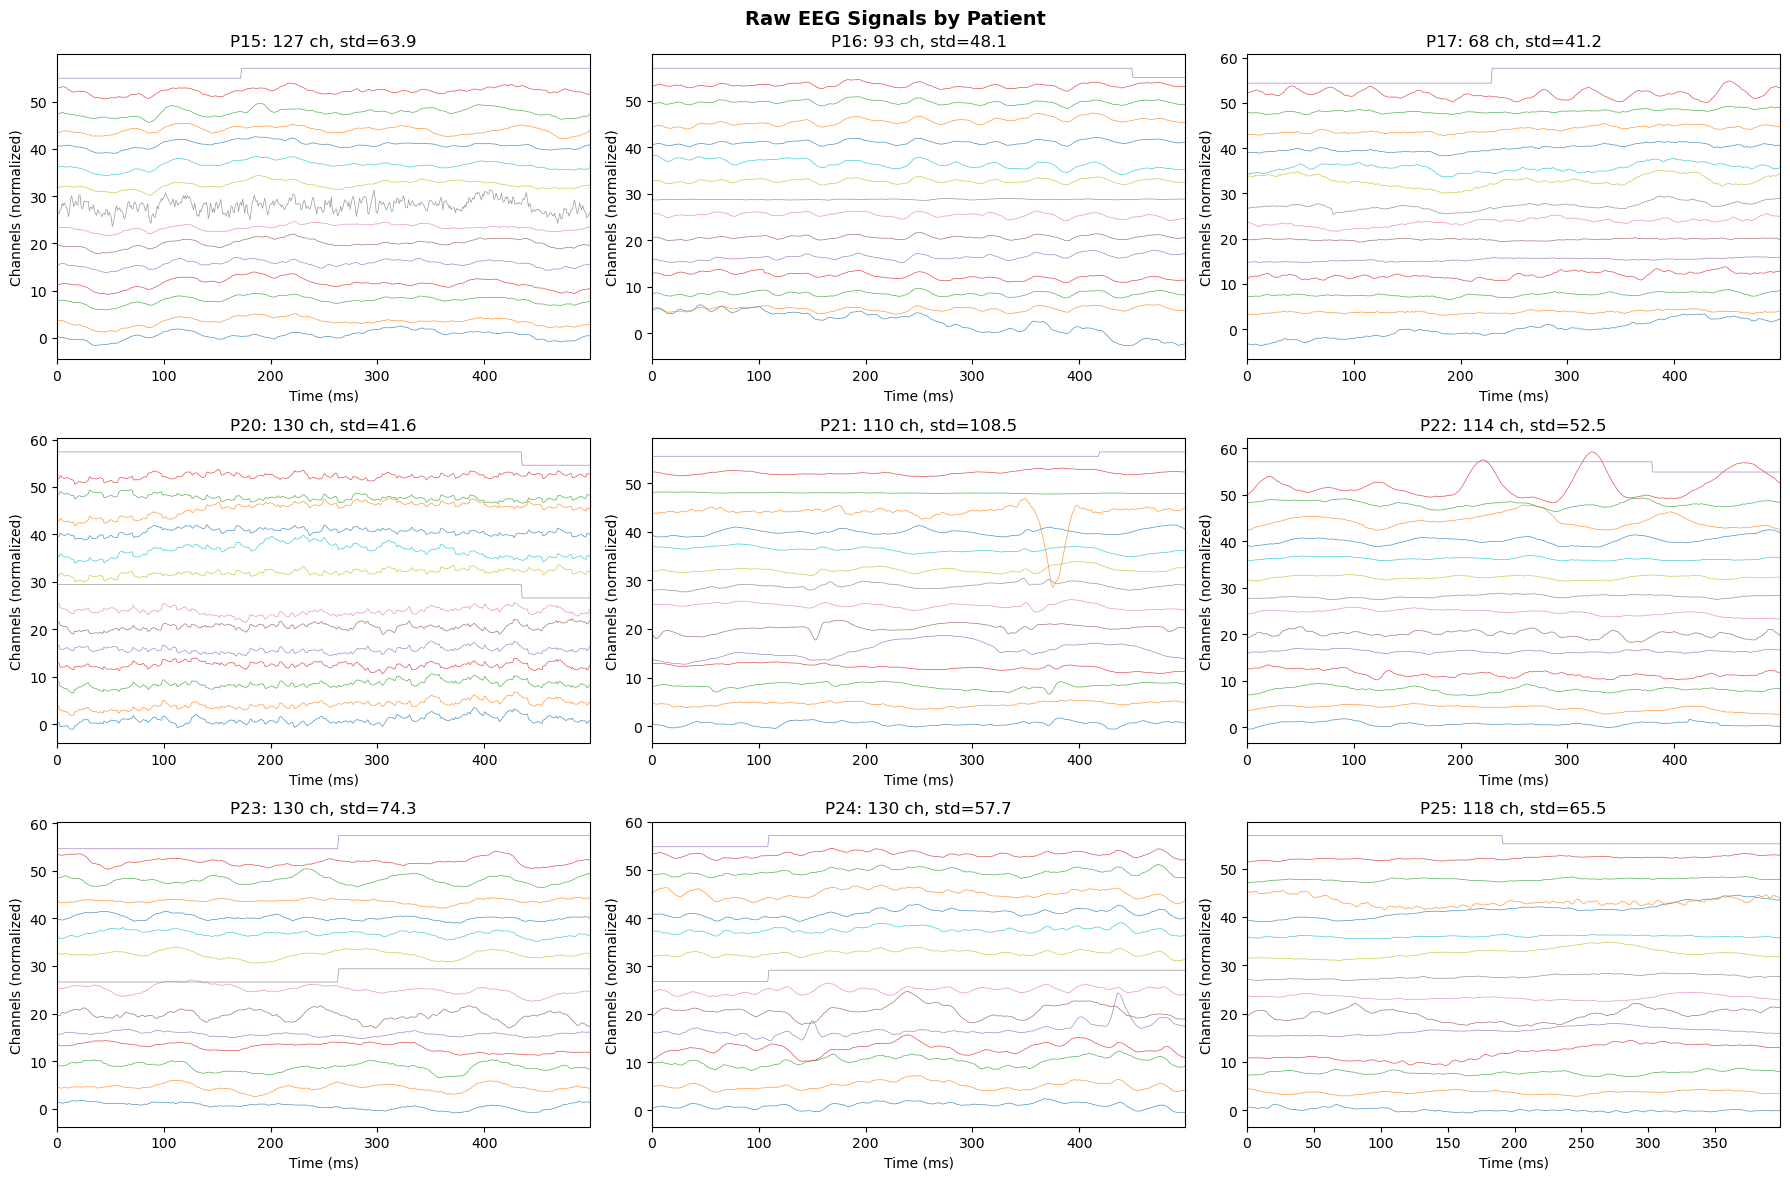


PATIENT SIGNAL STATISTICS
Patient    Channels   Std          Range        Mean|x|     
----------------------------------------------------------------------
P15        127        63.95        2495.90      42.02       
P16        93         48.06        1403.22      46.36       
P17        68         41.24        1692.87      25.41       
P20        130        41.62        1920.31      27.27       
P21        110        108.49       2361.91      78.80       
P22        114        52.49        1606.93      37.08       
P23        130        74.33        3210.45      50.00       
P24        130        57.68        1459.86      46.30       
P25        118        65.46        1158.20      44.03       

2. CHANNEL DISTRIBUTIONS


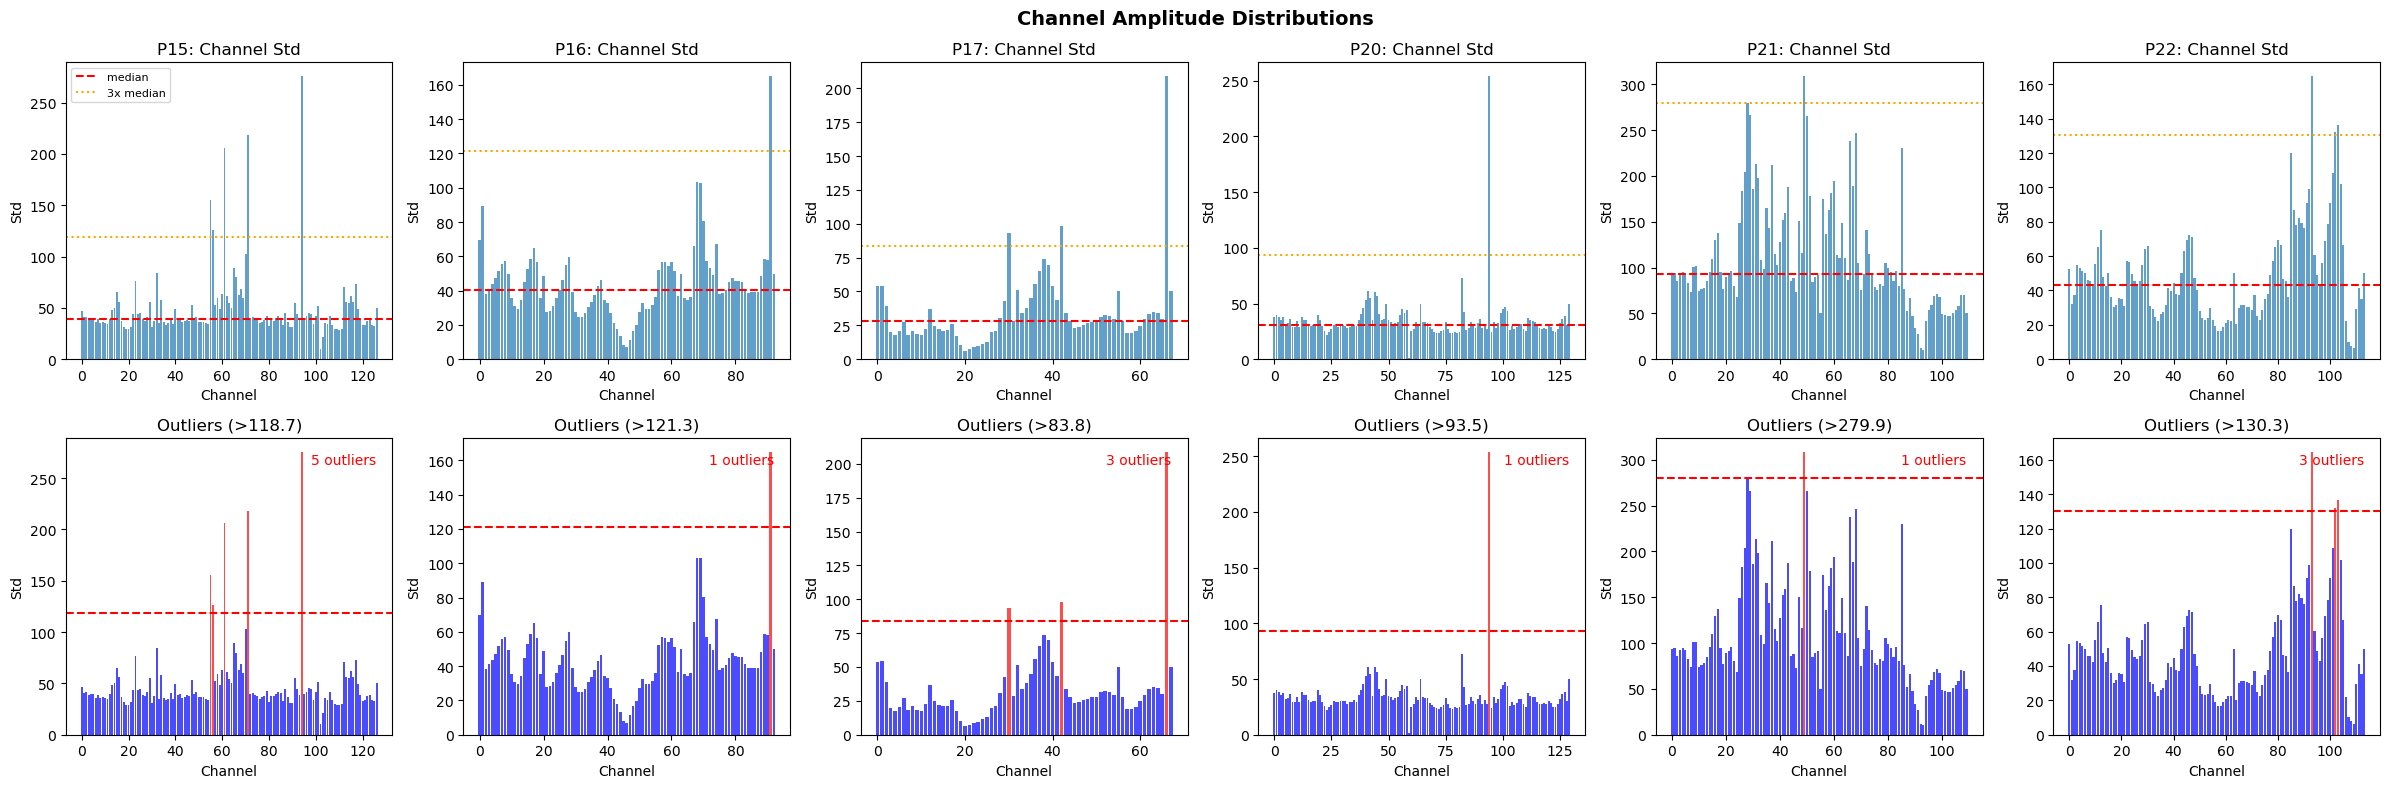


3. POWER SPECTRA


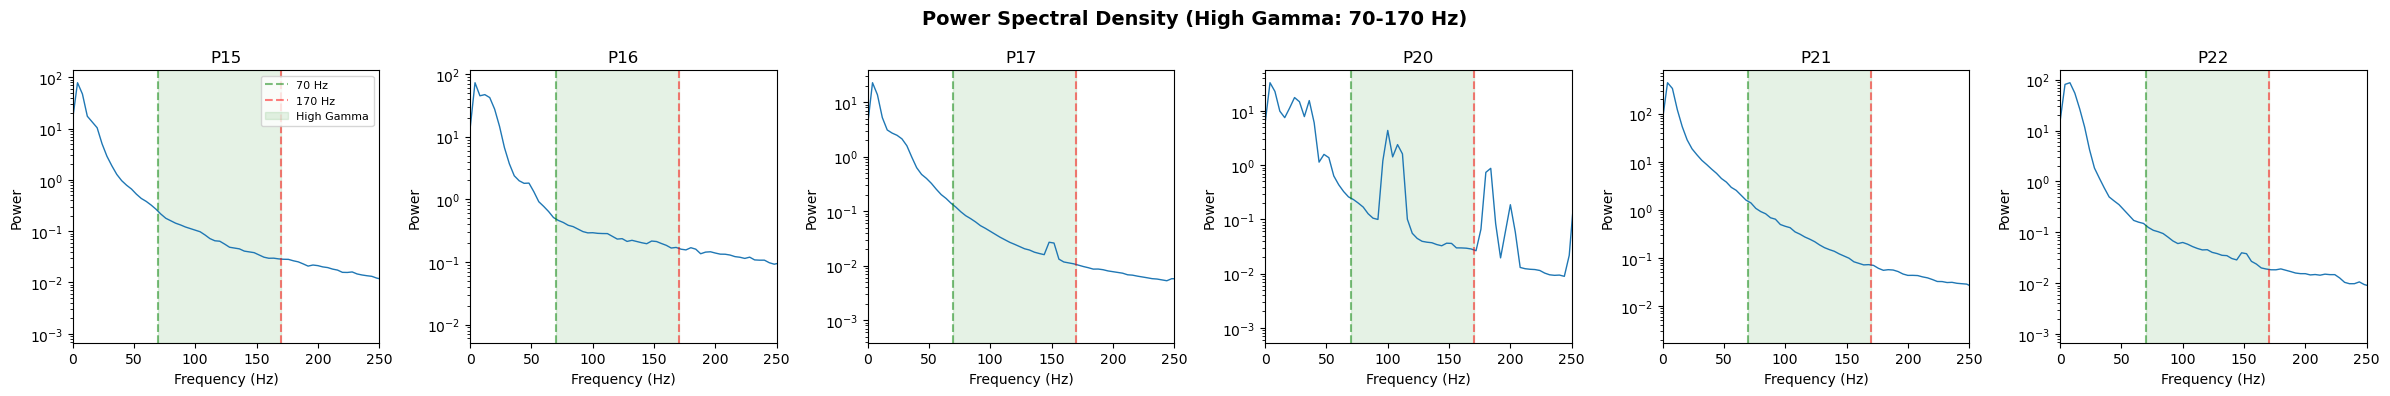


4. EXTRACTED FEATURES

FEATURE STATISTICS BY PATIENT
Patient    Samples    Mean         Std          Min          Max         
----------------------------------------------------------------------
P15        240        -0.7198      7.7583       -65.3775     276.4415    
P21        1159       -1.3198      5.4481       -21.5908     181.6921    
P24        1341       -0.3535      1.3881       -14.3640     43.3557     
P17        242        -0.2950      1.0876       -9.2439      24.7097     
P22        1399       -0.3119      1.0352       -4.1304      70.6855     
P16        240        -0.2177      1.0019       -15.7615     14.3649     
P20        234        -0.4651      1.5837       -5.6929      26.6724     
P25        1184       -0.5601      3.5960       -80.6790     60.8497     


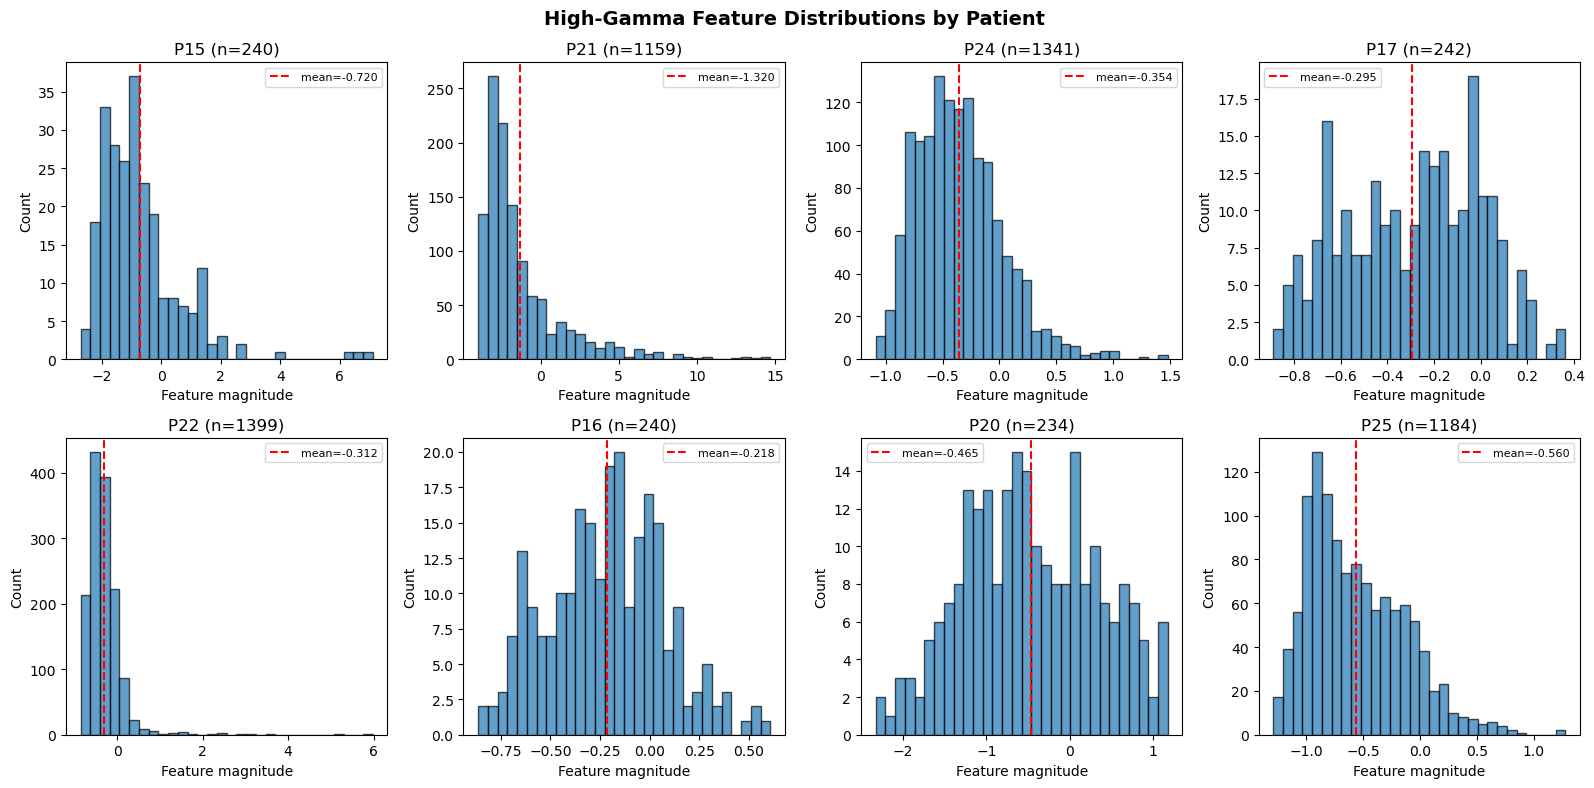

In [29]:
def visualize_patient_signals(pipeline, patient_ids=None, duration_sec=1.0, n_channels_to_show=20):
    """
    Visualize raw EEG signals for each patient to identify signal quality issues.
    
    Args:
        pipeline: Pipeline with loaded data
        patient_ids: List of patient IDs to visualize (default: all available)
        duration_sec: Duration of signal to show in seconds
        n_channels_to_show: Number of channels to display per patient
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    n_cols = min(3, n_patients)
    n_rows = (n_patients + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_patients == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    patient_stats = {}
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            ax.set_title(f"{pid}: No data")
            continue
        
        # Get first word's EEG segment
        words_data = word_segments_dict[pid]['words']
        first_word = list(words_data.keys())[0]
        eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
        
        n_samples = min(int(duration_sec * config.eeg_sr), eeg_segment.shape[0])
        n_channels = eeg_segment.shape[1]
        channels_to_plot = min(n_channels_to_show, n_channels)
        
        # Select evenly spaced channels
        channel_indices = np.linspace(0, n_channels-1, channels_to_plot, dtype=int)
        
        # Time axis
        time = np.arange(n_samples) / config.eeg_sr * 1000  # in ms
        
        # Plot each channel with offset
        eeg_subset = eeg_segment[:n_samples, channel_indices]
        
        # Normalize for visualization
        eeg_norm = eeg_subset / (np.std(eeg_subset) + 1e-10)
        
        # Add offset for each channel
        offsets = np.arange(channels_to_plot) * 4  # 4 std units between channels
        eeg_offset = eeg_norm + offsets
        
        for ch_idx in range(channels_to_plot):
            ax.plot(time, eeg_offset[:, ch_idx], linewidth=0.5, alpha=0.8)
        
        # Calculate stats
        signal_std = np.std(eeg_segment)
        signal_range = np.ptp(eeg_segment)
        signal_mean = np.mean(np.abs(eeg_segment))
        
        patient_stats[pid] = {
            'n_channels': n_channels,
            'std': signal_std,
            'range': signal_range,
            'mean_abs': signal_mean
        }
        
        ax.set_title(f"{pid}: {n_channels} ch, std={signal_std:.1f}")
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Channels (normalized)")
        ax.set_xlim([0, time[-1]])
    
    # Hide unused axes
    for idx in range(n_patients, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Raw EEG Signals by Patient", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("PATIENT SIGNAL STATISTICS")
    print("="*70)
    print(f"{'Patient':<10} {'Channels':<10} {'Std':<12} {'Range':<12} {'Mean|x|':<12}")
    print("-"*70)
    
    for pid in sorted(patient_stats.keys()):
        stats = patient_stats[pid]
        print(f"{pid:<10} {stats['n_channels']:<10} {stats['std']:<12.2f} "
              f"{stats['range']:<12.2f} {stats['mean_abs']:<12.2f}")
    
    return patient_stats


def visualize_channel_distributions(pipeline, patient_ids=None):
    """
    Show distribution of signal amplitude across channels for each patient.
    Helps identify outlier channels.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())[:6]
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(2, n_patients, figsize=(4*n_patients, 8))
    
    if n_patients == 1:
        axes = axes.reshape(2, 1)
    
    for idx, pid in enumerate(patient_ids):
        if pid not in word_segments_dict:
            continue
        
        # Collect EEG from multiple words
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:20]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        # Concatenate all segments
        eeg_concat = np.vstack(all_eeg)
        n_channels = eeg_concat.shape[1]
        
        # Calculate per-channel statistics
        channel_std = np.std(eeg_concat, axis=0)
        channel_mean = np.mean(eeg_concat, axis=0)
        channel_range = np.ptp(eeg_concat, axis=0)
        
        # Top plot: Channel std
        ax1 = axes[0, idx]
        ax1.bar(range(n_channels), channel_std, alpha=0.7)
        ax1.axhline(np.median(channel_std), color='r', linestyle='--', label='median')
        ax1.axhline(np.median(channel_std) * 3, color='orange', linestyle=':', label='3x median')
        ax1.set_title(f"{pid}: Channel Std")
        ax1.set_xlabel("Channel")
        ax1.set_ylabel("Std")
        if idx == 0:
            ax1.legend(fontsize=8)
        
        # Bottom plot: Identify outliers
        ax2 = axes[1, idx]
        median_std = np.median(channel_std)
        outlier_threshold = median_std * 3
        
        colors = ['red' if s > outlier_threshold else 'blue' for s in channel_std]
        ax2.bar(range(n_channels), channel_std, color=colors, alpha=0.7)
        ax2.axhline(outlier_threshold, color='red', linestyle='--')
        ax2.set_title(f"Outliers (>{outlier_threshold:.1f})")
        ax2.set_xlabel("Channel")
        ax2.set_ylabel("Std")
        
        # Count outliers
        n_outliers = sum(1 for s in channel_std if s > outlier_threshold)
        ax2.text(0.95, 0.95, f"{n_outliers} outliers", transform=ax2.transAxes,
                ha='right', va='top', fontsize=10, color='red')
    
    plt.suptitle("Channel Amplitude Distributions", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def visualize_signal_spectra(pipeline, patient_ids=None):
    """
    Show power spectral density for each patient to check frequency content.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import welch
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())[:6]
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(1, n_patients, figsize=(4*n_patients, 4))
    
    if n_patients == 1:
        axes = [axes]
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            continue
        
        # Get EEG data
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:10]:
            for instance in word_info['instances'][:2]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        eeg_concat = np.vstack(all_eeg)
        n_channels = eeg_concat.shape[1]
        
        # Compute average PSD across channels
        psds = []
        for ch in range(min(20, n_channels)):  # Sample 20 channels
            freqs, psd = welch(eeg_concat[:, ch], fs=config.eeg_sr, nperseg=256)
            psds.append(psd)
        
        avg_psd = np.mean(psds, axis=0)
        
        # Plot
        ax.semilogy(freqs, avg_psd, linewidth=1)
        ax.axvline(70, color='g', linestyle='--', alpha=0.5, label='70 Hz')
        ax.axvline(170, color='r', linestyle='--', alpha=0.5, label='170 Hz')
        ax.axvspan(70, 170, alpha=0.1, color='green', label='High Gamma')
        
        ax.set_title(f"{pid}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power")
        ax.set_xlim([0, 250])
        if idx == 0:
            ax.legend(fontsize=8)
    
    plt.suptitle("Power Spectral Density (High Gamma: 70-170 Hz)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_patient_features(pipeline, patient_ids=None):
    """
    Compare extracted high-gamma features across patients.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import defaultdict
    
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))[:8]
    
    train_data = pipeline.train
    
    # Group features by patient
    patient_features = defaultdict(list)
    
    for i, feat in enumerate(train_data['features']):
        pid = train_data['phoneme_participant_ids'][i]
        if pid in patient_ids:
            if feat.ndim > 1:
                feat_agg = feat.mean(axis=0)
            else:
                feat_agg = feat
            patient_features[pid].append(feat_agg)
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(2, min(4, n_patients), figsize=(16, 8))
    axes = axes.flatten()
    
    print("\n" + "="*70)
    print("FEATURE STATISTICS BY PATIENT")
    print("="*70)
    print(f"{'Patient':<10} {'Samples':<10} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-"*70)
    
    for idx, pid in enumerate(patient_ids[:8]):
        if pid not in patient_features:
            continue
        
        features = np.array(patient_features[pid])
        
        # Stats
        feat_mean = np.mean(features)
        feat_std = np.std(features)
        feat_min = np.min(features)
        feat_max = np.max(features)
        
        print(f"{pid:<10} {len(features):<10} {feat_mean:<12.4f} {feat_std:<12.4f} "
              f"{feat_min:<12.4f} {feat_max:<12.4f}")
        
        if idx < len(axes):
            ax = axes[idx]
            
            # Plot feature distribution (mean across channels)
            feature_means = np.mean(features, axis=1)
            ax.hist(feature_means, bins=30, alpha=0.7, edgecolor='black')
            ax.axvline(np.mean(feature_means), color='r', linestyle='--', 
                      label=f'mean={np.mean(feature_means):.3f}')
            ax.set_title(f"{pid} (n={len(features)})")
            ax.set_xlabel("Feature magnitude")
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
    
    # Hide unused axes
    for idx in range(len(patient_ids), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("High-Gamma Feature Distributions by Patient", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return patient_features


# Run all visualizations
print("1. RAW SIGNAL OVERVIEW")
patient_stats = visualize_patient_signals(high_gamma_pipeline, duration_sec=0.5, n_channels_to_show=15)

print("\n2. CHANNEL DISTRIBUTIONS")
visualize_channel_distributions(high_gamma_pipeline)

print("\n3. POWER SPECTRA")
visualize_signal_spectra(high_gamma_pipeline)

print("\n4. EXTRACTED FEATURES")
patient_features = compare_patient_features(high_gamma_pipeline)